# Deliverable 5 — Advanced Federated Methods and Architecture Study
**CS437/CS5317 Deep Learning, Spring 2026 | Group 30**
Muhammad Umar Malik (27100139) · Muhammad Moosa Kashif (27100451)

---

FT-k, Split-FL, and Ditto from D4 all failed to improve on FedAvg. They share a common failure mode: they personalise by moving parameters away from the global model, but the data shows the global model is already near-optimal for every client in parameter space. This notebook tests methods that either fix the global training process itself, or personalise in a fundamentally different space.

**SCAFFOLD** (Karimireddy et al., ICML 2020) corrects client drift during FedAvg training using per-client control variates. This is not a personalisation method — it produces a better global model. We test whether the D4 failures were partly caused by a drift-corrupted global initialisation, and re-run FT-k and Ditto on top of the SCAFFOLD global model.

**Per-FedAvg / FOMAML** (Fallah et al., NeurIPS 2020) trains the global model to be a good initialisation for per-client fine-tuning. Unlike Ditto, the global training objective itself changes: each client minimises the loss after one gradient step rather than directly minimising its local loss. This is MAML applied to federated learning.

**FedEM** (Marfoq et al., NeurIPS 2021) maintains M shared component models and lets each client learn a soft mixing vector over them. Personalisation happens in mixing-weight space, not parameter space — a fundamentally different approach from everything in D4.

**APFL** (Deng et al., 2020) maintains a global and a local model per client and mixes their outputs with a per-client scalar α optimised on the validation set.

**pFedGraph** (Ye et al., ICML 2023) personalises the aggregation step: instead of each client averaging all peers equally, it weights peers by gradient cosine similarity. We build this on top of SCAFFOLD.

Finally, we run a **Compact Transformer** architecture experiment to test whether the LSTM's recurrent inductive bias is responsible for the patterns we observe, or whether the findings are architecture-agnostic.

All methods use the same data, 30-stock universe, architecture (where applicable), 10 seeds, and evaluation pipeline as D3 and D4.

---
## Section 1 — Imports

In [1]:
import os
import time
import copy
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy.stats import wilcoxon
from scipy.optimize import minimize
import torch
import torch.nn as nn
import torch.nn.functional as F

warnings.filterwarnings('ignore')
os.makedirs('Figures_imp2', exist_ok=True)

print(f'PyTorch  : {torch.__version__}')
print(f'NumPy    : {np.__version__}')
print(f'Pandas   : {pd.__version__}')

PyTorch  : 2.10.0+cu128
NumPy    : 2.0.2
Pandas   : 2.3.3


---
## Section 2 — Configuration

In [2]:
# Paths
DATA_DIR    = '/kaggle/input/datasets/umarmalikk/updated-set/data'
FIGURES_DIR = 'Figures_imp2'

# Markets
MARKETS = ['SP500', 'FTSE100', 'KSE100', 'Nikkei225']

# Time splits (same as all previous deliverables)
TRAIN_END  = '2019-12-31'
VAL_START  = '2020-01-01'
VAL_END    = '2021-12-31'
TEST_START = '2022-01-01'
TEST_END   = '2026-04-01'

# Feature engineering
WINDOW       = 100    # lookback window (days)
TRADING_DAYS = 252

# Architecture (same as Improvement 1 D4)
HIDDEN_DIM = 96
N_LAYERS   = 2

# Training
LOCAL_EPOCHS  = 5
LOCAL_LR      = 5e-4
BATCH_SIZE    = 128
MAX_FL_ROUNDS = 150
PATIENCE      = 15

# Loss / evaluation
RF_ANNUAL  = 0.02
RF_DAILY   = RF_ANNUAL / TRADING_DAYS
TC         = 0.001      # 10bps one-way transaction cost
LAMBDA_TC  = 0.01       # TC penalty weight in training loss
GRAD_CLIP  = 1.0
STD_FLOOR  = 1e-4

# Statistics
SEEDS        = [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]
N_BOOTSTRAP  = 1000
BLOCK_SIZE   = 21       # ~1 trading month

# SCAFFOLD specific
# No extra hyperparameters — control variates have the same LR as local training

# Per-FedAvg (FOMAML) specific
PERFED_INNER_LR    = 5e-4   # inner loop learning rate (same as local LR)
PERFED_INNER_STEPS = 1      # number of inner gradient steps
PERFED_OUTER_LR    = 5e-4   # outer (meta) learning rate
PERFED_EVAL_STEPS  = [1, 3, 5]  # personalisation steps at test time

# FedEM specific
FEDEM_M        = 3      # number of mixture components
FEDEM_TEMP     = 1.0    # softmax temperature for E-step (higher = more uniform)
FEDEM_PATIENCE = 30     # longer than standard PATIENCE=15

# APFL specific
APFL_ALPHA_INIT = 0.5    # starting interpolation weight (0=fully global, 1=fully local)
APFL_ALPHA_LR   = 0.01   # learning rate for alpha (learned per client on val set)

# Regimes
REGIMES = {
    '2022 (Inflation shock)' : ('2022-01-01', '2022-12-31'),
    '2023 (Recovery)'        : ('2023-01-01', '2023-12-31'),
    '2024+ (Late cycle)'     : ('2024-01-01', '2026-04-01'),
}

# D3 baseline numbers (from baselines notebook on new data)
D3_SHARPE = {
    'Local'  : {'SP500': 0.8927, 'FTSE100': 0.4642, 'KSE100': 0.8235, 'Nikkei225': 0.7618},
    'FedAvg' : {'SP500': 0.9498, 'FTSE100': 0.5099, 'KSE100': 0.9375, 'Nikkei225': 0.8664},
}

# D4 FedAvg numbers (from Improvement 1 on new data)
D4_FEDAVG = {'SP500': 0.8823, 'FTSE100': 0.4636, 'KSE100': 0.9314, 'Nikkei225': 0.9259}

# Heterogeneity scores (from dataset notebook on new data)
# HD: Hellinger Distance (market-level mean returns, KDE, training period)
HD_SCORES = {'SP500': 0.0818, 'FTSE100': 0.0920, 'KSE100': 0.0732, 'Nikkei225': 0.1133}
# Idiosyncrasy: 1 - R² with federation average return
IDIO_SCORES = {'SP500': 0.591, 'FTSE100': 0.505, 'KSE100': 0.750, 'Nikkei225': 0.536}

COLORS = {
    'SP500'    : '#1f77b4',
    'FTSE100'  : '#ff7f0e',
    'KSE100'   : '#2ca02c',
    'Nikkei225': '#d62728',
}

device = torch.device(
    'cuda' if torch.cuda.is_available() else
    'mps'  if torch.backends.mps.is_available() else 'cpu')

print('Configuration loaded.')
print(f'  Architecture : hidden={HIDDEN_DIM}, layers={N_LAYERS}')
print(f'  Training     : epochs={LOCAL_EPOCHS}, lr={LOCAL_LR}, batch={BATCH_SIZE}')
print(f'  FL           : max_rounds={MAX_FL_ROUNDS}, patience={PATIENCE}')
print(f'  FedEM        : M={FEDEM_M} components')
print(f'  Per-FedAvg   : inner_steps={PERFED_INNER_STEPS}, eval_steps={PERFED_EVAL_STEPS}')
print(f'  Seeds        : {SEEDS}')
print(f'  Device       : {device}')

Configuration loaded.
  Architecture : hidden=96, layers=2
  Training     : epochs=5, lr=0.0005, batch=128
  FL           : max_rounds=150, patience=15
  FedEM        : M=3 components
  Per-FedAvg   : inner_steps=1, eval_steps=[1, 3, 5]
  Seeds        : [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]
  Device       : cuda


---
## Section 3 — Data Loading

In [3]:
def load_prices(market):
    path = os.path.join(DATA_DIR, f'{market}_prices.csv')
    df   = pd.read_csv(path, index_col=0, parse_dates=True)
    return df.sort_index()

def compute_log_returns(prices_df):
    filled = prices_df.ffill()
    return np.log(filled / filled.shift(1)).dropna(how='all')

def make_splits(returns_df):
    return {
        'train': returns_df.loc[:TRAIN_END],
        'val'  : returns_df.loc[VAL_START:VAL_END],
        'test' : returns_df.loc[TEST_START:TEST_END],
    }

prices  = {m: load_prices(m)                 for m in MARKETS}
returns = {m: compute_log_returns(prices[m]) for m in MARKETS}
splits  = {m: make_splits(returns[m])        for m in MARKETS}

rows = []
for m in MARKETS:
    p, s = prices[m], splits[m]
    rows.append({'Market': m, 'Assets': p.shape[1],
                 'Train': len(s['train']), 'Val': len(s['val']), 'Test': len(s['test'])})
print(pd.DataFrame(rows).set_index('Market').to_string())

           Assets  Train  Val  Test
Market                             
SP500          30   2515  505  1064
FTSE100        30   2525  507  1071
KSE100         30   2478  498  1051
Nikkei225      30   2468  487  1036


In [4]:
def engineer_features(ret_df):
    R = ret_df.ffill().fillna(0.0)
    frames = [
        R.copy(),
        R.rolling(5,  min_periods=1).mean(),
        R.rolling(20, min_periods=2).std().fillna(0.0),
        (R.rolling(20, min_periods=2).mean() /
         R.rolling(20, min_periods=2).std().replace(0, np.nan)).fillna(0.0),
        R.rolling(20, min_periods=3).skew().fillna(0.0),
        R.rolling(60, min_periods=1).sum(),
    ]
    combined = pd.concat(frames, axis=1)
    combined.columns = [f'f{k}_{c}' for k in range(6) for c in R.columns]
    return combined.iloc[60:].copy()

def fit_normaliser(feat_df):
    mu  = feat_df.mean()
    sig = feat_df.std().replace(0, 1.0)
    return mu, sig

def apply_normaliser(feat_df, mu, sig, clip=5.0):
    return ((feat_df - mu) / sig).clip(-clip, clip)

def make_sequences(feat_df, ret_df, window=WINDOW):
    feat_arr = feat_df.values.astype(np.float32)
    ret_arr  = ret_df.reindex(feat_df.index).ffill().fillna(0.0).values.astype(np.float32)
    X, y = [], []
    for i in range(window, len(feat_arr)):
        X.append(feat_arr[i - window : i])
        y.append(ret_arr[i])
    return (torch.from_numpy(np.array(X, dtype=np.float32)).to(device),
            torch.from_numpy(np.array(y, dtype=np.float32)).to(device))

print(f'Building features (6/asset) for window={WINDOW}d...')

features_all = {m: engineer_features(returns[m]) for m in MARKETS}
normalisers  = {}
train_seq    = {}
val_seq      = {}
test_seq     = {}
n_assets     = {m: prices[m].shape[1] for m in MARKETS}
n_features   = {}

for m in MARKETS:
    f_all = features_all[m]
    f_tr  = f_all.loc[:TRAIN_END]
    f_v   = f_all.loc[VAL_START:VAL_END]
    f_te  = f_all.loc[TEST_START:TEST_END]
    mu, sig = fit_normaliser(f_tr)
    normalisers[m] = (mu, sig)
    train_seq[m]  = make_sequences(apply_normaliser(f_tr, mu, sig), splits[m]['train'])
    val_seq[m]    = make_sequences(apply_normaliser(f_v,  mu, sig), splits[m]['val'])
    test_seq[m]   = make_sequences(apply_normaliser(f_te, mu, sig), splits[m]['test'])
    n_features[m] = train_seq[m][0].shape[2]
    print(f'  {m:<12}  X_train={tuple(train_seq[m][0].shape)}')

Building features (6/asset) for window=100d...
  SP500         X_train=(2355, 100, 180)
  FTSE100       X_train=(2365, 100, 180)
  KSE100        X_train=(2318, 100, 180)
  Nikkei225     X_train=(2308, 100, 180)


---
## Section 4 — Model Definition

In [5]:
class LSTMPortfolio(nn.Module):
    """
    2-layer LSTM followed by a softmax output layer.
    Input:  (batch, window, n_features)
    Output: (batch, n_assets)  — portfolio weights summing to 1
    """
    def __init__(self, n_features, n_assets,
                 hidden=HIDDEN_DIM, n_layers=N_LAYERS, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden, n_layers,
                            batch_first=True, dropout=dropout if n_layers > 1 else 0.0)
        self.head = nn.Linear(hidden, n_assets)
        self.drop = nn.Dropout(p=dropout)

    def forward(self, x):
        out, _ = self.lstm(x)
        return torch.softmax(self.head(self.drop(out[:, -1, :])), dim=-1)

# Sanity check
_m = LSTMPortfolio(n_features['SP500'], n_assets['SP500']).to(device)
_x = torch.zeros(2, WINDOW, n_features['SP500']).to(device)
assert _m(_x).shape == (2, n_assets['SP500'])
n_params = sum(p.numel() for p in _m.parameters())
print(f'LSTMPortfolio : {n_params:,} params')
del _m, _x

LSTMPortfolio : 184,158 params


---
## Section 5 — Loss Function and Evaluation

In [6]:
def sharpe_loss(weights, next_rets, prev_weights=None):
    port_ret = (weights * next_rets).sum(dim=1)
    excess   = port_ret - RF_DAILY
    mean_e   = excess.mean()
    std_e    = excess.std().clamp(min=STD_FLOOR)
    tc_pen   = 0.0
    if prev_weights is not None and prev_weights.shape == weights.shape:
        tc_pen = LAMBDA_TC * (weights - prev_weights).abs().sum(dim=1).mean()
    return -(mean_e / std_e) + tc_pen

def compute_metrics(daily_rets):
    """Full set of portfolio metrics from a daily return array."""
    daily_rets = np.array(daily_rets)
    ann_ret = daily_rets.mean() * TRADING_DAYS
    ann_vol = daily_rets.std()  * np.sqrt(TRADING_DAYS)
    excess  = daily_rets - RF_DAILY
    sharpe  = (excess.mean() / excess.std().clip(1e-8)) * np.sqrt(TRADING_DAYS)

    neg     = daily_rets[daily_rets < 0]
    sortino = (excess.mean() / neg.std().clip(1e-8)) * np.sqrt(TRADING_DAYS) if len(neg) > 0 else np.nan

    cum     = np.cumprod(1 + daily_rets)
    dd      = (cum - np.maximum.accumulate(cum)) / np.maximum.accumulate(cum)
    max_dd  = dd.min()
    calmar  = ann_ret / abs(max_dd).clip(1e-8)

    return {'sharpe': sharpe, 'sortino': sortino, 'calmar': calmar,
            'ann_ret': ann_ret, 'ann_vol': ann_vol, 'max_dd': max_dd,
            'daily_rets': daily_rets, 'cum_ret': cum}

@torch.no_grad()
def evaluate_portfolio(model, X, y):
    """Run model on test sequences, apply TC, return metrics."""
    model.eval()
    w      = model(X).cpu().numpy()
    r      = y.cpu().numpy()
    n      = len(w)
    rets   = []
    w_prev = np.ones(w.shape[1]) / w.shape[1]
    for i in range(n):
        port_ret = (w[i] * r[i]).sum()
        tc_cost  = TC * np.abs(w[i] - w_prev).sum()
        rets.append(port_ret - tc_cost)
        w_prev = w[i]
    return {**compute_metrics(np.array(rets)), 'weights': w}

print('Loss and evaluation defined.')

Loss and evaluation defined.


---
## Section 6 — Statistical Tests

Primary test: block bootstrap on daily returns (5,000 resamples, block=21 trading days). This uses the actual return distribution over ~1,000 test-period observations and is more powerful than the seed-level Sharpe tests for detecting the differences we care about.

Secondary test: dual JK + Wilcoxon on the 10 per-seed Sharpe values (both p<0.05 required). Reported alongside bootstrap results as a robustness check.

In [7]:
def jk_test(sharpes_a, sharpes_b):
    """
    Jobson-Korkie test with Memmel (2003) variance correction.
    Tests H0: Sharpe(A) = Sharpe(B).
    Returns two-tailed p-value.
    """
    n   = len(sharpes_a)
    d   = np.array(sharpes_a) - np.array(sharpes_b)
    mu  = d.mean()
    se  = d.std(ddof=1) / np.sqrt(n)
    se  = max(se, 1.0 / np.sqrt(n))   # SE floor to avoid near-zero theta
    from scipy.stats import norm
    z   = mu / se
    return float(2 * (1 - norm.cdf(abs(z))))

def dual_test(sharpes_a, sharpes_b):
    """
    Returns (jk_p, wil_p, significant).
    Significant = both JK p<0.05 AND Wilcoxon p<0.05.
    """
    jk_p  = jk_test(sharpes_a, sharpes_b)
    d     = np.array(sharpes_a) - np.array(sharpes_b)
    if np.all(d == 0):
        wil_p = 1.0
    else:
        try:
            _, wil_p = wilcoxon(d)
        except Exception:
            wil_p = 1.0
    sig = (jk_p < 0.05) and (wil_p < 0.05)
    direction = '+' if np.mean(d) > 0 else '-'
    label = f'{direction}{direction}' if sig else '.'
    return jk_p, wil_p, label

def block_bootstrap_ci(daily_rets, n_boot=N_BOOTSTRAP, block=BLOCK_SIZE, alpha=0.05):
    """Block bootstrap 95% CI for Sharpe ratio."""
    rets  = np.array(daily_rets)
    T     = len(rets)
    boots = []
    for _ in range(n_boot):
        indices = []
        while len(indices) < T:
            start = np.random.randint(0, T - block + 1)
            indices.extend(range(start, min(start + block, T)))
        sample = rets[indices[:T]]
        exc    = sample - RF_DAILY
        s      = (exc.mean() / exc.std().clip(1e-8)) * np.sqrt(TRADING_DAYS)
        boots.append(s)
    boots = np.array(boots)
    return boots.mean(), boots.std(), np.percentile(boots, 100*alpha/2), np.percentile(boots, 100*(1-alpha/2))

def regime_sharpe(daily_rets, dates):
    """Compute Sharpe per regime from a daily return array."""
    out = {}
    for name, (s, e) in REGIMES.items():
        mask = (dates >= s) & (dates <= e)
        r    = daily_rets[mask]
        if len(r) > 20:
            exc = r - RF_DAILY
            out[name] = (exc.mean() / exc.std().clip(1e-8)) * np.sqrt(TRADING_DAYS)
        else:
            out[name] = np.nan
    return out

print('Statistical tests defined.')
print('  Dual criterion: JK (Memmel 2003) + Wilcoxon signed-rank, both p<0.05')

Statistical tests defined.
  Dual criterion: JK (Memmel 2003) + Wilcoxon signed-rank, both p<0.05


---
## Section 7 — Local Training Utility

In [8]:
def local_train(model, X_tr, y_tr,
                epochs=LOCAL_EPOCHS, lr=LOCAL_LR, bs=BATCH_SIZE,
                grad_correction=None):
    lm = LSTMPortfolio(model.lstm.input_size, model.head.out_features).to(device)
        lm.load_state_dict(model.state_dict())
    opt = torch.optim.Adam(lm.parameters(), lr=lr)
    lm.train()
    N = X_tr.shape[0]
    for _ in range(epochs):
        perm   = torch.randperm(N, device=device)
        prev_w = None
        for start in range(0, N, bs):
            idx      = perm[start:start + bs]
            x_b, y_b = X_tr[idx], y_tr[idx]
            w_b      = lm(x_b)
            loss     = sharpe_loss(w_b, y_b, prev_w)
            opt.zero_grad()
            loss.backward()
            if grad_correction is not None:
                with torch.no_grad():
                    for name, param in lm.named_parameters():
                        if param.grad is not None and name in grad_correction:
                            param.grad.add_(grad_correction[name])
            nn.utils.clip_grad_norm_(lm.parameters(), GRAD_CLIP)
            opt.step()
            prev_w = w_b.detach()
    return {k: v.clone() for k, v in lm.state_dict().items()}

print('Local training utility defined.')

Local training utility defined.


---
## Section 8 — FedAvg Baseline

FedAvg is re-run here so all comparisons in this notebook use models trained under the same environment and seeds. Results should match D4 closely.

In [9]:
def fedavg_aggregate(state_dicts, weights=None):
    """Weighted average of model state dicts. Default: equal weights."""
    if weights is None:
        weights = [1.0 / len(state_dicts)] * len(state_dicts)
    agg = {}
    for key in state_dicts[0]:
        agg[key] = sum(w * sd[key].float() for w, sd in zip(weights, state_dicts))
    return agg

def make_model(market, seed=None):
    if seed is not None:
        torch.manual_seed(seed)
    return LSTMPortfolio(n_features[market], n_assets[market]).to(device)

def run_fedavg(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    
    models = {m: make_model(m, seed) for m in MARKETS}
    
    best_agg  = -np.inf
    best_sd   = {m: copy.deepcopy(models[m].state_dict()) for m in MARKETS}
    no_improve = 0
    
    for rnd in range(MAX_FL_ROUNDS):
        # Local training
        local_sds = {m: local_train(models[m], *train_seq[m]) for m in MARKETS}
        
        # aggregate
        agg_sd = fedavg_aggregate(list(local_sds.values()))
        
        for m in MARKETS:
            models[m].load_state_dict(agg_sd)
        
        # Validation
        val_sharpes = {m: evaluate_portfolio(models[m], *val_seq[m])['sharpe'] for m in MARKETS}
        mean_val    = np.mean(list(val_sharpes.values()))
        
        mean_val = np.mean(list(val_sharpes.values()))
        if mean_val > best_agg + 1e-4:
            best_agg = mean_val
            for m in MARKETS:
                best_sd[m] = copy.deepcopy(models[m].state_dict())
            no_improve = 0
        else:
            no_improve += 1
        if no_improve >= PATIENCE:
            break
    
    # Load best checkpoints
    for m in MARKETS:
        models[m].load_state_dict(best_sd[m])
    
    return models, rnd + 1

print('Running FedAvg (10 seeds x up to 150 rounds)...')
print('='*65)
t0 = time.time()
fedavg_sharpes  = {m: [] for m in MARKETS}
fedavg_daily    = {m: [] for m in MARKETS}
fedavg_models_s42 = None
stop_rounds = []

for i, seed in enumerate(SEEDS):
    if (i % 5 == 0) or i == len(SEEDS)-1:
        print(f'  Seed {seed} ({i+1}/{len(SEEDS)})')
    models, n_rds = run_fedavg(seed)
    stop_rounds.append(n_rds)
    if seed == 42:
        fedavg_models_s42 = {m: copy.deepcopy(models[m]) for m in MARKETS}
    for m in MARKETS:
        res = evaluate_portfolio(models[m], *test_seq[m])
        fedavg_sharpes[m].append(res['sharpe'])
        fedavg_daily[m].append(res['daily_rets'])

elapsed = (time.time() - t0) / 60
print(f'Done in {elapsed:.1f} min | mean stop round: {np.mean(stop_rounds):.1f}')
print()
print(f'  {"Market":<12}  {"FedAvg (new)":>14}  {"D4 Imp1":>10}  {"Delta":>8}')
print('  ' + '-'*50)
for m in MARKETS:
    mean_s = np.mean(fedavg_sharpes[m])
    delta  = mean_s - D4_FEDAVG[m]
    print(f'  {m:<12}  {mean_s:>+14.4f}  {D4_FEDAVG[m]:>10.4f}  {delta:>+8.4f}')

Running FedAvg (10 seeds x up to 150 rounds)...
  Seed 42 (1/10)
  Seed 47 (6/10)
  Seed 51 (10/10)
Done in 7.4 min | mean stop round: 16.5

  Market          FedAvg (new)     D4 Imp1     Delta
  --------------------------------------------------
  SP500                +0.9174      0.8823   +0.0351
  FTSE100              +0.5166      0.4636   +0.0530
  KSE100               +0.9492      0.9314   +0.0178
  Nikkei225            +0.9171      0.9259   -0.0088


In [10]:
print("SP500 std across 10 seeds:")
print(f"  mean={np.mean(fedavg_sharpes['SP500']):.4f}  std={np.std(fedavg_sharpes['SP500']):.4f}")
print()
print("All seeds SP500:")
for s, v in zip(SEEDS, fedavg_sharpes['SP500']):
    print(f"  seed={s}: {v:+.4f}")

SP500 std across 10 seeds:
  mean=0.9174  std=0.0943

All seeds SP500:
  seed=42: +0.9862
  seed=43: +0.9996
  seed=44: +0.8000
  seed=45: +0.7357
  seed=46: +1.0226
  seed=47: +1.0062
  seed=48: +0.8832
  seed=49: +0.8435
  seed=50: +0.9091
  seed=51: +0.9883


---
## Section 9 — SCAFFOLD
### Karimireddy et al., ICML 2020

**The problem.** In standard FedAvg, multiple local gradient steps cause each client's model to drift away from where a centralised gradient would have taken it. This client drift accumulates across rounds and is a main source of variance across seeds. Our SP500 seed std of ~0.094 is consistent with this.

**How it works.** Each client maintains a control variate $c_i$ and the server maintains $c$. During local training, instead of following the raw local gradient $g_i$, each client follows:
$$g_i^{\text{corrected}} = g_i - c_i + c$$

After local training, the client updates its control variate:
$$c_i^{\text{new}} = c_i - c + \frac{1}{KE\eta}(x - y_i)$$

where $x$ is the pre-training global model, $y_i$ is the post-training client model, $K$ is batches per epoch, $E$ is local epochs, and $\eta$ is the local learning rate.

**Key property.** SCAFFOLD is unbiased — it converges to the same solution as FedAvg but with lower variance and faster convergence. If the D4 personalisation failures were caused by a noisy global initialisation, SCAFFOLD should change the picture.

**What we check.** Seed std across markets (should drop significantly), mean Sharpe (should improve or stay flat), and then whether FT-k and Ditto on the SCAFFOLD global model behave differently from D4.

In [11]:
def run_scaffold(seed):
    """
    SCAFFOLD federated training.
    
    Each client maintains a control variate c_i (same shape as model params).
    Server maintains global control variate c.
    Correction applied during local gradient steps.
    """
    torch.manual_seed(seed)
    np.random.seed(seed)
    
    # Initialise models
    models  = {m: make_model(m, seed) for m in MARKETS}
    
    # Initialise control variates to zero for all clients and server
    # c_i: per-client, per-parameter tensor
    # c:   global server control variate
    def zero_cv(model):
        return {name: torch.zeros_like(param).to(device)
                for name, param in model.named_parameters()}
    
    client_cv = {m: zero_cv(models[m]) for m in MARKETS}  # c_i
    server_cv = zero_cv(models[MARKETS[0]])                 # c (shared architecture)
    
    best_agg = -np.inf
    best_sd    = {m: copy.deepcopy(models[m].state_dict()) for m in MARKETS}
    no_improve = 0
    
    for rnd in range(MAX_FL_ROUNDS):
        local_sds  = {}
        delta_cvs  = {}   # change in each client's control variate this round
        
        for m in MARKETS:
            # Save global model state before local training
            global_params = {name: param.data.clone()
                             for name, param in models[m].named_parameters()}
            
            # Build gradient correction for this client:
            # correction = -c_i + c  (subtract client CV, add server CV)
            correction = {}
            for name in client_cv[m]:
                if name in server_cv:
                    correction[name] = -client_cv[m][name] + server_cv[name]
            
            # Local training with SCAFFOLD correction
            local_sd = local_train(models[m], *train_seq[m],
                                   grad_correction=correction)
            local_sds[m] = local_sd
            
            # Load the locally trained weights so param.data reflects post-training state
            models[m].load_state_dict(local_sd)
            
            # Update client control variate
            # c_i^new = c_i - c + (1 / (K*E*lr)) * (global - local)
            # global_params = weights before local training (saved above)
            # param.data    = weights after  local training (just loaded)
            K = len(train_seq[m][0]) // BATCH_SIZE  # batches per epoch
            scale = 1.0 / (K * LOCAL_EPOCHS * LOCAL_LR)
            
            new_cv = {}
            for name, param in models[m].named_parameters():
                if name in server_cv:
                    delta = scale * (global_params[name] - param.data)
                    new_cv[name] = client_cv[m][name] - server_cv[name] + delta
                    
            delta_cvs[m] = {name: new_cv[name] - client_cv[m][name]
                            for name in new_cv}
            client_cv[m] = new_cv
        
        # Aggregate model updates (same as FedAvg)
        agg_sd = fedavg_aggregate(list(local_sds.values()))
        for m in MARKETS:
            models[m].load_state_dict(agg_sd)
        
        # Update server control variate: c = c + (1/n) * sum(delta_c_i)
        n_clients = len(MARKETS)
        for name in server_cv:
            server_cv[name] = server_cv[name] + (1.0 / n_clients) * sum(
                delta_cvs[m][name] for m in MARKETS if name in delta_cvs[m])
        
        # Validation
        val_sharpes = {m: evaluate_portfolio(models[m], *val_seq[m])['sharpe']
                       for m in MARKETS}
        mean_val = np.mean(list(val_sharpes.values()))
        if mean_val > best_agg + 1e-4:
            best_agg = mean_val
            for m in MARKETS:
                best_sd[m] = copy.deepcopy(models[m].state_dict())
            no_improve = 0
        else:
            no_improve += 1
        if no_improve >= PATIENCE:
            break
    
    for m in MARKETS:
        models[m].load_state_dict(best_sd[m])
    
    return models, rnd + 1

print('Running SCAFFOLD (10 seeds x up to 150 rounds)...')
print('='*65)
t0 = time.time()
scaffold_sharpes       = {m: [] for m in MARKETS}
scaffold_daily         = {m: [] for m in MARKETS}
scaffold_models_s42    = None
scaffold_stop_rounds   = []
scaffold_trained_models = {}

for i, seed in enumerate(SEEDS):
    if (i % 5 == 0) or i == len(SEEDS)-1:
        print(f'  Seed {seed} ({i+1}/{len(SEEDS)})')
    scaffold_models, n_rds = run_scaffold(seed)
    scaffold_trained_models[seed] = {m: copy.deepcopy(scaffold_models[m]) for m in MARKETS}
    scaffold_stop_rounds.append(n_rds)
    if seed == 42:
        scaffold_models_s42 = {m: copy.deepcopy(scaffold_models[m]) for m in MARKETS}
    for m in MARKETS:
        res = evaluate_portfolio(scaffold_models[m], *test_seq[m])
        scaffold_sharpes[m].append(res['sharpe'])
        scaffold_daily[m].append(res['daily_rets'])

elapsed = (time.time() - t0) / 60
print(f'Done in {elapsed:.1f} min | mean stop round: {np.mean(scaffold_stop_rounds):.1f}')
print()
print(f'  {"Market":<12}  {"SCAFFOLD":>10}  {"std":>8}  {"FedAvg":>10}  {"Delta":>8}  {"Sig"}')
print('  ' + '-'*60)
for m in MARKETS:
    sc_mean = np.mean(scaffold_sharpes[m])
    sc_std  = np.std(scaffold_sharpes[m])
    fa_mean = np.mean(fedavg_sharpes[m])
    _, _, sig = dual_test(scaffold_sharpes[m], fedavg_sharpes[m])
    print(f'  {m:<12}  {sc_mean:>+10.4f}  {sc_std:>8.4f}  {fa_mean:>+10.4f}  {sc_mean-fa_mean:>+8.4f}  {sig}')

Running SCAFFOLD (10 seeds x up to 150 rounds)...
  Seed 42 (1/10)
  Seed 47 (6/10)
  Seed 51 (10/10)
Done in 13.5 min | mean stop round: 30.0

  Market          SCAFFOLD       std      FedAvg     Delta  Sig
  ------------------------------------------------------------
  SP500            +0.9994    0.0116     +0.9174   +0.0820  .
  FTSE100          +0.5960    0.0202     +0.5166   +0.0794  .
  KSE100           +0.9850    0.0201     +0.9492   +0.0358  .
  Nikkei225        +0.9109    0.0138     +0.9171   -0.0063  .


### SCAFFOLD — FT-k on top

If SCAFFOLD gives a cleaner global model, does fine-tuning on top of it help? We test the same k grid as D4 but starting from the SCAFFOLD global model rather than the plain FedAvg global model.

In [12]:
def ftk_from_model(base_models, k, ft_lr=5e-4):
    """Fine-tune each client's copy of base_model for k steps on local training data."""
    results = {}
    for m in MARKETS:
        model = copy.deepcopy(base_models[m])
        if k == 0:
            results[m] = model
            continue
        model.train()
        opt = torch.optim.Adam(model.parameters(), lr=ft_lr)
        X_tr, y_tr = train_seq[m]
        N = X_tr.shape[0]
        steps_done = 0
        for epoch in range(100):
            perm = torch.randperm(N)
            for start in range(0, N, BATCH_SIZE):
                if steps_done >= k:
                    break
                idx  = perm[start:start + BATCH_SIZE]
                loss = sharpe_loss(model(X_tr[idx]), y_tr[idx])
                opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                opt.step()
                steps_done += 1
            if steps_done >= k:
                break
        results[m] = model
    return results

K_GRID = [0, 1, 3, 5, 10]
print('FT-k on SCAFFOLD global model (10 seeds x 5 k-values)...')
t0 = time.time()

scaffold_ftk = {k: {m: [] for m in MARKETS} for k in K_GRID}

for i, seed in enumerate(SEEDS):
    sc_models = scaffold_trained_models[seed]  # no retraining needed
    for k in K_GRID:
        ft_models = ftk_from_model(sc_models, k)
        for m in MARKETS:
            res = evaluate_portfolio(ft_models[m], *test_seq[m])
            scaffold_ftk[k][m].append(res['sharpe'])
    if (i % 5 == 0) or i == len(SEEDS) - 1:
        print(f'  Seed {seed} ({i+1}/{len(SEEDS)}) done')

print(f'Done in {(time.time()-t0)/60:.1f} min')
print()
print(f'  {"k":<5}  {"SP500":>10}  {"FTSE100":>10}  {"KSE100":>10}  {"Nikkei225":>10}')
print('  ' + '-'*50)
for k in K_GRID:
    row = f'  {k:<5}'
    for m in MARKETS:
        row += f'  {np.mean(scaffold_ftk[k][m]):>+10.4f}'
    print(row)

FT-k on SCAFFOLD global model (10 seeds x 5 k-values)...
  Seed 42 (1/10) done
  Seed 47 (6/10) done
  Seed 51 (10/10) done
Done in 0.2 min

  k           SP500     FTSE100      KSE100   Nikkei225
  --------------------------------------------------
  0         +0.9994     +0.5960     +0.9850     +0.9109
  1         +0.9985     +0.5950     +0.9850     +0.9103
  3         +0.9980     +0.5922     +0.9834     +0.9085
  5         +0.9983     +0.5923     +0.9858     +0.9073
  10        +0.9940     +0.5869     +0.9832     +0.9048


### SCAFFOLD — Ditto on top

In [13]:
def ditto_from_model(base_models, mu, seed):
    """
    Ditto personalisation starting from base_models (SCAFFOLD global).
    Each client minimises: L_local(w) + (mu/2) * ||w - w_global||^2
    """
    torch.manual_seed(seed)
    results = {}
    for m in MARKETS:
        global_model = copy.deepcopy(base_models[m])
        local_model  = copy.deepcopy(base_models[m])
        global_params = {name: param.data.clone().detach()
                         for name, param in global_model.named_parameters()}
        
        local_model.train()
        opt = torch.optim.Adam(local_model.parameters(), lr=LOCAL_LR)
        X_tr, y_tr = train_seq[m]
        N = X_tr.shape[0]
        
        best_val_s = -np.inf
        best_sd    = copy.deepcopy(local_model.state_dict())
        no_imp     = 0
        
        for epoch in range(50):
            perm = torch.randperm(N)
            for start in range(0, N, BATCH_SIZE):
                idx  = perm[start:start + BATCH_SIZE]
                loss = sharpe_loss(local_model(X_tr[idx]), y_tr[idx])
                
                # Proximal term: (mu/2) * ||w - w_global||^2
                prox = 0.0
                for name, param in local_model.named_parameters():
                    if name in global_params:
                        prox = prox + (mu / 2.0) * ((param - global_params[name]) ** 2).sum()
                
                total = loss + prox
                opt.zero_grad()
                total.backward()
                nn.utils.clip_grad_norm_(local_model.parameters(), GRAD_CLIP)
                opt.step()
            
            val_s = evaluate_portfolio(local_model, *val_seq[m])['sharpe']
            local_model.train()
            if val_s > best_val_s:
                best_val_s = val_s
                best_sd = copy.deepcopy(local_model.state_dict())
                no_imp  = 0
            else:
                no_imp += 1
            if no_imp >= 5:
                break
        
        local_model.load_state_dict(best_sd)
        results[m] = local_model
    return results


MU_GRID = [0.01, 0.1, 0.3, 1.0]
print('Ditto mu selection on SCAFFOLD global (seed=42, val Sharpe)...')

best_mu = {}
for m in MARKETS:
    best_mu_m, best_val_m = None, -np.inf
    for mu in MU_GRID:
        ditto_m = ditto_from_model(
            {mm: copy.deepcopy(scaffold_models_s42[mm]) for mm in MARKETS}, mu, 42)
        val_s = evaluate_portfolio(ditto_m[m], *val_seq[m])['sharpe']
        if val_s > best_val_m:
            best_val_m = val_s
            best_mu_m  = mu
    best_mu[m] = best_mu_m

print(f'  Selected mu: {best_mu}')
print()
print('Running Ditto on SCAFFOLD (10 seeds)...')
t0 = time.time()
scaffold_ditto_sharpes = {m: [] for m in MARKETS}
scaffold_ditto_daily   = {m: [] for m in MARKETS}

for seed in SEEDS:
    sc_models = scaffold_trained_models[seed]   # reuse — no retraining
    for m in MARKETS:
        mu_m = best_mu[m]
        dm   = ditto_from_model(sc_models, mu_m, seed)
        res  = evaluate_portfolio(dm[m], *test_seq[m])
        scaffold_ditto_sharpes[m].append(res['sharpe'])
        scaffold_ditto_daily[m].append(res['daily_rets'])

print(f'Done in {(time.time()-t0)/60:.1f} min')
print()
print(f'  {"Market":<12}  {"Ditto+SC":>10}  {"SCAFFOLD":>10}  {"Delta":>8}  {"Sig"}')
print('  ' + '-'*55)
for m in MARKETS:
    d_mean = np.mean(scaffold_ditto_sharpes[m])
    s_mean = np.mean(scaffold_sharpes[m])
    _, _, sig = dual_test(scaffold_ditto_sharpes[m], scaffold_sharpes[m])
    print(f'  {m:<12}  {d_mean:>+10.4f}  {s_mean:>+10.4f}  {d_mean-s_mean:>+8.4f}  {sig}')

Ditto mu selection on SCAFFOLD global (seed=42, val Sharpe)...
  Selected mu: {'SP500': 0.01, 'FTSE100': 1.0, 'KSE100': 0.01, 'Nikkei225': 0.01}

Running Ditto on SCAFFOLD (10 seeds)...
Done in 5.0 min

  Market          Ditto+SC    SCAFFOLD     Delta  Sig
  -------------------------------------------------------
  SP500            +0.9415     +0.9994   -0.0579  .
  FTSE100          +0.5948     +0.5960   -0.0012  .
  KSE100           +0.8682     +0.9850   -0.1168  .
  Nikkei225        +0.7624     +0.9109   -0.1484  .


---
## Section 10 — Per-FedAvg (FOMAML)
### Fallah et al., NeurIPS 2020

**The idea.** Ditto fails because the global model has no better nearby local optimum for any client. But Ditto trains the global model the same way as FedAvg — to minimise the average loss directly. Per-FedAvg trains a different global model: one shaped to be a good initialisation for per-client adaptation.

**How it works.** Each client minimises the loss after one gradient step rather than the direct local loss:
$$\min_w \, \mathcal{L}_i(w - \alpha \nabla \mathcal{L}_i(w))$$

This trains $w$ to be a point from which one gradient step on any client's data yields a good model. We use the first-order approximation (FOMAML) which drops the second-order term — much cheaper and works nearly as well in practice.

**Evaluation.** At test time we take the global model and run k gradient steps on each client's training data (k=1, 3, 5). We compare against both FedAvg and the unadapted Per-FedAvg global model (k=0).

In [14]:
def run_perfedavg(seed):
    """
    Per-FedAvg with first-order MAML approximation (FOMAML).
    
    Each round:
    1. For each client: take one inner gradient step on a local mini-batch
    2. At the adapted parameters, compute loss on a different mini-batch
    3. Backprop through that outer loss to get the meta-gradient
    4. Restore original parameters, aggregate meta-gradients, update global model
    
    We avoid torch.func.functional_call because it does not work cleanly
    with nn.LSTM on CUDA (flattened weight buffers cause silent failures).
    Instead we step in-place, compute the outer loss, then restore.
    """
    torch.manual_seed(seed)
    np.random.seed(seed)

    models    = {m: make_model(m, seed) for m in MARKETS}
    best_agg  = -np.inf
    best_sd   = {m: copy.deepcopy(models[m].state_dict()) for m in MARKETS}
    no_improve = 0

    for rnd in range(MAX_FL_ROUNDS):
        meta_grads = {m: None for m in MARKETS}

        for m in MARKETS:
            X_tr, y_tr = train_seq[m]
            N = X_tr.shape[0]

            # Two independent mini-batches: one for inner step, one for outer loss
            idx_inner = torch.randperm(N)[:BATCH_SIZE]
            idx_outer = torch.randperm(N)[:BATCH_SIZE]
            X_in,  y_in  = X_tr[idx_inner], y_tr[idx_inner]
            X_out, y_out = X_tr[idx_outer],  y_tr[idx_outer]

            models[m].train()

            # Inner step
            # Compute gradient of local loss at current parameters
            loss_inner  = sharpe_loss(models[m](X_in), y_in)
            grads_inner = torch.autograd.grad(
                loss_inner, models[m].parameters(),
                create_graph=False, allow_unused=True)

            # Save current parameters so we can restore after outer step
            orig_params = [p.data.clone() for p in models[m].parameters()]

            # Apply inner step in-place: theta' = theta - alpha * grad_inner
            with torch.no_grad():
                for p, g in zip(models[m].parameters(), grads_inner):
                    if g is not None:
                        p.data -= PERFED_INNER_LR * g

            # Outer step (FOMAML)
            # Compute outer loss at adapted parameters theta'
            # FOMAML approximation: gradient flows through theta' only,
            # not back through the inner-step computation graph
            loss_outer = sharpe_loss(models[m](X_out), y_out)
            meta_grad  = torch.autograd.grad(
                loss_outer, models[m].parameters(),
                allow_unused=True)

            meta_grads[m] = [g.detach() if g is not None else None
                             for g in meta_grad]

            # Restore original parameters before aggregation
            with torch.no_grad():
                for p, orig in zip(models[m].parameters(), orig_params):
                    p.data.copy_(orig)

        # Aggregate meta-gradients and update each model
        for m in MARKETS:
            if meta_grads[m] is not None:
                opt = torch.optim.Adam(models[m].parameters(), lr=PERFED_OUTER_LR)
                opt.zero_grad()
                for param, grad in zip(models[m].parameters(), meta_grads[m]):
                    if grad is not None:
                        param.grad = grad.clone()
                nn.utils.clip_grad_norm_(models[m].parameters(), GRAD_CLIP)
                opt.step()

        # Share LSTM backbone across markets
        # Each market has a different head (output dim = n_assets),
        # so we aggregate only the backbone and keep heads private.
        backbone_sds = [{k: v for k, v in models[m].state_dict().items()
                         if 'head' not in k}
                        for m in MARKETS]
        agg_backbone = fedavg_aggregate(backbone_sds)
        for m in MARKETS:
            sd = models[m].state_dict()
            sd.update(agg_backbone)
            models[m].load_state_dict(sd)

        # Validation: 1-step personalised model
        val_sharpes = {}
        for m in MARKETS:
            X_v, y_v = val_seq[m]
            adapted   = copy.deepcopy(models[m])
            adapted.train()
            opt_a = torch.optim.Adam(adapted.parameters(), lr=PERFED_INNER_LR)
            X_tr, y_tr = train_seq[m]
            idx        = torch.randperm(X_tr.shape[0])[:BATCH_SIZE]
            loss_a     = sharpe_loss(adapted(X_tr[idx]), y_tr[idx])
            opt_a.zero_grad()
            loss_a.backward()
            nn.utils.clip_grad_norm_(adapted.parameters(), GRAD_CLIP)
            opt_a.step()
            val_sharpes[m] = evaluate_portfolio(adapted, X_v, y_v)['sharpe']

        mean_val = np.mean(list(val_sharpes.values()))
        if mean_val > best_agg + 1e-4:
            best_agg = mean_val
            for m in MARKETS:
                best_sd[m] = copy.deepcopy(models[m].state_dict())
            no_improve = 0
        else:
            no_improve += 1
        if no_improve >= PATIENCE:
            break

    for m in MARKETS:
        models[m].load_state_dict(best_sd[m])

    return models, rnd + 1


def personalise_model(global_model, market, k_steps, lr=PERFED_INNER_LR):
    """
    Take the Per-FedAvg global model and run k gradient steps on the
    market's training data. The global model is the meta-learned
    initialisation — k steps should quickly adapt it to the local optimum.
    Returns a new model; does not modify the original.
    """
    model = copy.deepcopy(global_model)
    if k_steps == 0:
        return model
    model.train()
    opt   = torch.optim.Adam(model.parameters(), lr=lr)
    X_tr, y_tr = train_seq[market]
    N     = X_tr.shape[0]
    steps = 0
    for epoch in range(100):
        perm = torch.randperm(N)
        for start in range(0, N, BATCH_SIZE):
            if steps >= k_steps:
                break
            idx  = perm[start:start + BATCH_SIZE]
            loss = sharpe_loss(model(X_tr[idx]), y_tr[idx])
            opt.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            opt.step()
            steps += 1
        if steps >= k_steps:
            break
    return model


print('Running Per-FedAvg / FOMAML (10 seeds x up to 150 rounds)...')
print('='*65)
t0 = time.time()

perfedavg_sharpes        = {k: {m: [] for m in MARKETS} for k in PERFED_EVAL_STEPS}
perfedavg_daily          = {k: {m: [] for m in MARKETS} for k in PERFED_EVAL_STEPS}
perfedavg_global_sharpes = {m: [] for m in MARKETS}
pf_stop_rounds           = []

for i, seed in enumerate(SEEDS):
    if (i % 5 == 0) or i == len(SEEDS) - 1:
        print(f'  Seed {seed} ({i+1}/{len(SEEDS)})')

    global_models, n_rds = run_perfedavg(seed)
    pf_stop_rounds.append(n_rds)

    # k=0: global model as-is (no personalisation steps)
    for m in MARKETS:
        res = evaluate_portfolio(global_models[m], *test_seq[m])
        perfedavg_global_sharpes[m].append(res['sharpe'])

    # k>0: personalise with k gradient steps then evaluate
    for k in PERFED_EVAL_STEPS:
        for m in MARKETS:
            pers_model = personalise_model(global_models[m], m, k)
            res        = evaluate_portfolio(pers_model, *test_seq[m])
            perfedavg_sharpes[k][m].append(res['sharpe'])
            perfedavg_daily[k][m].append(res['daily_rets'])

elapsed = (time.time() - t0) / 60
print(f'Done in {elapsed:.1f} min | mean stop round: {np.mean(pf_stop_rounds):.1f}')
print()
print(f'  {"k":<12}  {"SP500":>10}  {"FTSE100":>10}  {"KSE100":>10}  {"Nikkei225":>10}')
print('  ' + '-'*55)
print(f'  {"0 (global)":<12}', end='')
for m in MARKETS:
    print(f'  {np.mean(perfedavg_global_sharpes[m]):>+10.4f}', end='')
print()
for k in PERFED_EVAL_STEPS:
    print(f'  {k:<12}', end='')
    for m in MARKETS:
        print(f'  {np.mean(perfedavg_sharpes[k][m]):>+10.4f}', end='')
    print()

Running Per-FedAvg / FOMAML (10 seeds x up to 150 rounds)...
  Seed 42 (1/10)
  Seed 47 (6/10)
  Seed 51 (10/10)
Done in 0.8 min | mean stop round: 32.8

  k                  SP500     FTSE100      KSE100   Nikkei225
  -------------------------------------------------------
  0 (global)       +1.0156     +0.6091     +0.9911     +0.9203
  1                +1.0150     +0.6087     +0.9914     +0.9201
  3                +1.0150     +0.6085     +0.9917     +0.9196
  5                +1.0147     +0.6078     +0.9912     +0.9193


In [15]:
# Debug: check what the Per-FedAvg global model actually learned
# If training ran correctly, seed=42 global model should differ from
# a fresh untrained model with the same seed

fresh = make_model('SP500', 42)
trained = global_models['SP500']  # last seed's model from the loop

fresh_params   = torch.cat([p.data.flatten() for p in fresh.parameters()])
trained_params = torch.cat([p.data.flatten() for p in trained.parameters()])
diff = (fresh_params - trained_params).abs().mean().item()

print(f'Mean abs param difference (fresh vs trained): {diff:.6f}')
print(f'If near zero, training did not run.')
print(f'If > 0.01, training ran correctly.')
print()
print(f'MAX_FL_ROUNDS = {MAX_FL_ROUNDS}')
print(f'PATIENCE = {PATIENCE}')
print(f'PERFED_INNER_LR = {PERFED_INNER_LR}')
print(f'PERFED_OUTER_LR = {PERFED_OUTER_LR}')
print(f'PERFED_EVAL_STEPS = {PERFED_EVAL_STEPS}')

Mean abs param difference (fresh vs trained): 0.068129
If near zero, training did not run.
If > 0.01, training ran correctly.

MAX_FL_ROUNDS = 150
PATIENCE = 15
PERFED_INNER_LR = 0.0005
PERFED_OUTER_LR = 0.0005
PERFED_EVAL_STEPS = [1, 3, 5]


---
## Section 11 — FedEM
### Marfoq et al., NeurIPS 2021

**The motivation.** Every method tested so far moves parameters away from the global optimum, and the data consistently shows that hurts. FedEM personalises in a completely different space: the mixing weights over M shared component models.

**How it works.** FedEM maintains M global component models. Each client $i$ has a mixing weight vector $\lambda_i \in \Delta^M$. The client's personalised prediction is $\sum_m \lambda_{im} \theta_m$.

Training alternates between two steps:

**E-step** (update mixing weights): For fixed components, each client up-weights the components that perform best on its local data:
$$\lambda_{im} \propto \lambda_{im} \cdot \exp(-\mathcal{L}_i(\theta_m) / \tau)$$

**M-step** (update components): For fixed mixing weights, each component is updated by FedAvg weighted by how much each client uses it:
$$\theta_m \leftarrow \text{FedAvg}\left(\{(\nabla \mathcal{L}_i(\theta_m), \lambda_{im})\}_{i}\right)$$

**Key property.** Every component is trained on all clients' data (weighted). No client ever loses the federation signal — it just learns to mix the globally-trained components differently.

In [16]:
from scipy.stats import entropy as sp_entropy


def run_fedem(seed, M=FEDEM_M, temperature=FEDEM_TEMP, verbose=False):
    """
    FedEM: Federated EM with M component models.
    
    Each market has its own architecture (different n_assets),
    so we maintain M component models per market.
    The mixing weights are per-client — each market learns how much
    to weight each component.
    
    Key difference from parameter-space personalisation:
    component models are trained on ALL clients' data (weighted).
    Each client never loses the federation signal — it just learns
    how to mix the globally-trained components.
    
    Returns:
      component_models: dict market -> list of M models
      mixing_weights:   dict market -> np.array of shape (M,)
      stop_round:       int
    """
    torch.manual_seed(seed)
    np.random.seed(seed)

    # Each component gets a different seed so they start from different
    # initialisations and can specialise into different regimes.
    component_models = {
        m: [make_model(m, seed * 100 + k) for k in range(M)]
        for m in MARKETS
    }

    mixing_weights = {m: np.ones(M) / M for m in MARKETS}

    best_agg            = -np.inf
    best_val_per_market = {m: -np.inf for m in MARKETS}

    # Best checkpoints stored per market independently.
    # This prevents one unstable client (e.g. FTSE100 during M-step)
    # from forcing an early rollback that discards good mixing vectors
    # that other clients have already learned.
    best_comp = {m: [copy.deepcopy(component_models[m][k].state_dict())
                     for k in range(M)] for m in MARKETS}
    best_lam  = {m: mixing_weights[m].copy() for m in MARKETS}
    best_kl_per_market = {}
    no_improve = 0

    for rnd in range(MAX_FL_ROUNDS):

        # E-step: update mixing weights per client
        # For each client, evaluate each component on a local mini-batch
        # and update mixing weights toward the better-performing components.
        for m in MARKETS:
            X_tr, y_tr = train_seq[m]
            idx  = torch.randperm(X_tr.shape[0])[:BATCH_SIZE]
            X_b, y_b = X_tr[idx], y_tr[idx]

            component_losses = []
            for k in range(M):
                component_models[m][k].eval()
                with torch.no_grad():
                    w_k      = component_models[m][k](X_b)
                    port_ret = (w_k * y_b).sum(dim=1)
                    exc      = port_ret - RF_DAILY
                    loss_k   = -(exc.mean() / exc.std().clamp(STD_FLOOR)).item()
                component_losses.append(loss_k)

            # Log-space softmax update for numerical stability
            log_lam = np.log(mixing_weights[m] + 1e-10) - np.array(component_losses) / temperature
            log_lam -= log_lam.max()
            new_lam  = np.exp(log_lam)
            mixing_weights[m] = new_lam / new_lam.sum()

        # M-step: update each component model
        # Component k is updated by aggregating local updates from all
        # clients, weighted by how much each client uses component k.
        # Clients with near-zero weight for a component skip it entirely.
        for k in range(M):
            weighted_sds = []
            weights_k    = []

            for m in MARKETS:
                lam_mk = mixing_weights[m][k]
                if lam_mk < 1e-6:
                    continue
                model_k  = copy.deepcopy(component_models[m][k])
                local_sd = local_train(model_k, *train_seq[m], epochs=1)
                weighted_sds.append(local_sd)
                weights_k.append(lam_mk)

            if len(weighted_sds) == 0:
                continue

            total_w = sum(weights_k)
            norm_w  = [w / total_w for w in weights_k]
            agg_sd  = fedavg_aggregate(weighted_sds, norm_w)

            for m in MARKETS:
                component_models[m][k].load_state_dict(agg_sd)

        # Validation: evaluate mixture model per client
        val_sharpes = {}
        for m in MARKETS:
            X_v, y_v = val_seq[m]
            with torch.no_grad():
                for k in range(M):
                    component_models[m][k].eval()
                mixture_w = sum(mixing_weights[m][k] * component_models[m][k](X_v)
                                for k in range(M))
            port_ret = (mixture_w.cpu() * y_v.cpu()).sum(dim=1)
            exc      = port_ret - RF_DAILY
            sharpe   = (exc.mean() / exc.std().clamp(STD_FLOOR)).item() * np.sqrt(TRADING_DAYS)
            val_sharpes[m] = sharpe

        if verbose and rnd % 10 == 0:
            lam_str = {m: np.round(mixing_weights[m], 3) for m in MARKETS}
            print(f'  Round {rnd:3d}: val_sharpes={dict((m, round(v, 3)) for m, v in val_sharpes.items())}')
            print(f'             mixing={lam_str}')

        # Early stopping
        # Checkpoint criterion: save per market when val Sharpe is above a
        # minimum floor AND the mixing vector is more specialised (higher KL
        # from uniform) than any previously saved state for that market.
        # This prevents the uniform initial weights from being the best
        # checkpoint simply because early val Sharpe happens to be highest.
        uniform_lam = np.ones(M) / M

        for m in MARKETS:
            kl_m = sp_entropy(mixing_weights[m] + 1e-10, uniform_lam + 1e-10)
            if val_sharpes[m] > 0.1 and kl_m > best_kl_per_market.get(m, 0):
                best_kl_per_market[m] = kl_m
                best_comp[m] = [copy.deepcopy(component_models[m][k].state_dict())
                                for k in range(M)]
                best_lam[m]  = mixing_weights[m].copy()

        mean_val = np.mean(list(val_sharpes.values()))
        if mean_val > best_agg + 1e-4:
            best_agg   = mean_val
            no_improve = 0
        else:
            no_improve += 1
        if no_improve >= FEDEM_PATIENCE:
            break

    # Restore best per-market checkpoints
    for m in MARKETS:
        mixing_weights[m] = best_lam[m]
        for k in range(M):
            component_models[m][k].load_state_dict(best_comp[m][k])

    return component_models, mixing_weights, rnd + 1


@torch.no_grad()
def evaluate_mixture(component_models, mixing_weights, market):
    """
    Evaluate mixture model on test set with transaction costs.
    Iterates one sample at a time to apply TC correctly between
    consecutive time steps.
    """
    X_te, y_te = test_seq[market]
    for k in range(FEDEM_M):
        component_models[market][k].eval()

    w_all = []
    for i in range(len(X_te)):
        x_i       = X_te[i:i+1]
        mixture_w = sum(mixing_weights[market][k] * component_models[market][k](x_i)
                        for k in range(FEDEM_M))
        w_all.append(mixture_w.cpu().numpy()[0])

    w_arr  = np.array(w_all)
    r_arr  = y_te.cpu().numpy()
    rets   = []
    w_prev = np.ones(w_arr.shape[1]) / w_arr.shape[1]
    for i in range(len(w_arr)):
        port_ret = (w_arr[i] * r_arr[i]).sum()
        tc_cost  = TC * np.abs(w_arr[i] - w_prev).sum()
        rets.append(port_ret - tc_cost)
        w_prev = w_arr[i]

    return {**compute_metrics(np.array(rets)), 'weights': w_arr}


# Seed=42 diagnostic: do components differentiate?
print('FedEM DIAGNOSTIC — seed=42, checking if components differentiate...')
print('='*65)
comp_diag, lam_diag, rds_diag = run_fedem(42, verbose=True)
print(f'Stopped at round {rds_diag}')
print()
print('Mixing weights at convergence (seed=42):')
print(f'  {"Market":<12}  ' + '  '.join(f'{"λ_"+str(k):>8}' for k in range(FEDEM_M)))
print('  ' + '-'*50)
for m in MARKETS:
    row = f'  {m:<12}'
    for k in range(FEDEM_M):
        row += f'  {lam_diag[m][k]:>8.4f}'
    print(row)

print()
from scipy.stats import entropy as sp_entropy
print('KL divergence from uniform (higher = more specialised mixing):')
uniform = np.ones(FEDEM_M) / FEDEM_M
for m in MARKETS:
    kl = sp_entropy(lam_diag[m] + 1e-10, uniform + 1e-10)
    print(f'  {m:<12}: KL = {kl:.4f}  idiosyncrasy = {IDIO_SCORES[m]:.3f}')

FedEM DIAGNOSTIC — seed=42, checking if components differentiate...
  Round   0: val_sharpes={'SP500': np.float64(2.001), 'FTSE100': np.float64(0.503), 'KSE100': np.float64(0.493), 'Nikkei225': np.float64(1.228)}
             mixing={'SP500': array([0.334, 0.333, 0.333]), 'FTSE100': array([0.333, 0.334, 0.333]), 'KSE100': array([0.333, 0.333, 0.334]), 'Nikkei225': array([0.334, 0.332, 0.333])}
  Round  10: val_sharpes={'SP500': np.float64(2.001), 'FTSE100': np.float64(0.318), 'KSE100': np.float64(0.474), 'Nikkei225': np.float64(1.305)}
             mixing={'SP500': array([0.331, 0.332, 0.336]), 'FTSE100': array([0.33 , 0.337, 0.333]), 'KSE100': array([0.329, 0.334, 0.336]), 'Nikkei225': array([0.335, 0.332, 0.333])}
  Round  20: val_sharpes={'SP500': np.float64(2.178), 'FTSE100': np.float64(0.041), 'KSE100': np.float64(0.569), 'Nikkei225': np.float64(0.965)}
             mixing={'SP500': array([0.348, 0.313, 0.339]), 'FTSE100': array([0.316, 0.354, 0.33 ]), 'KSE100': array([0.333, 0.28

In [17]:
# Full 10-seed run
print('Running FedEM full (10 seeds x up to 150 rounds)...')
print('='*65)
t0 = time.time()

fedem_sharpes  = {m: [] for m in MARKETS}
fedem_daily    = {m: [] for m in MARKETS}
fedem_mixing   = {m: [] for m in MARKETS}  # mixing weights per seed
fedem_stop_rounds = []

for i, seed in enumerate(SEEDS):
    if (i % 5 == 0) or i == len(SEEDS)-1:
        print(f'  Seed {seed} ({i+1}/{len(SEEDS)})')
    comp_m, lam_m, n_rds = run_fedem(seed)
    fedem_stop_rounds.append(n_rds)
    for m in MARKETS:
        res = evaluate_mixture(comp_m, lam_m, m)
        fedem_sharpes[m].append(res['sharpe'])
        fedem_daily[m].append(res['daily_rets'])
        fedem_mixing[m].append(lam_m[m].copy())

elapsed = (time.time() - t0) / 60
print(f'Done in {elapsed:.1f} min | mean stop round: {np.mean(fedem_stop_rounds):.1f}')
print()
print(f'  {"Market":<12}  {"FedEM":>10}  {"std":>8}  {"FedAvg":>10}  {"Delta":>8}  {"Sig"}')
print('  ' + '-'*60)
for m in MARKETS:
    fe_mean = np.mean(fedem_sharpes[m])
    fe_std  = np.std(fedem_sharpes[m])
    fa_mean = np.mean(fedavg_sharpes[m])
    _, _, sig = dual_test(fedem_sharpes[m], fedavg_sharpes[m])
    print(f'  {m:<12}  {fe_mean:>+10.4f}  {fe_std:>8.4f}  {fa_mean:>+10.4f}  {fe_mean-fa_mean:>+8.4f}  {sig}')

print()
print('Mean mixing weights across 10 seeds:')
print(f'  {"Market":<12}  ' + '  '.join(f'{"λ_"+str(k):>8}' for k in range(FEDEM_M)) + '  {"KL_unif":>10}')
from scipy.stats import entropy
uniform = np.ones(FEDEM_M) / FEDEM_M
for m in MARKETS:
    mean_lam = np.mean(fedem_mixing[m], axis=0)
    kl = entropy(mean_lam + 1e-10, uniform + 1e-10)
    row = f'  {m:<12}'
    for k in range(FEDEM_M):
        row += f'  {mean_lam[k]:>8.4f}'
    row += f'  {kl:>10.4f}'
    print(row)

Running FedEM full (10 seeds x up to 150 rounds)...
  Seed 42 (1/10)
  Seed 47 (6/10)
  Seed 51 (10/10)
Done in 12.5 min | mean stop round: 41.1

  Market             FedEM       std      FedAvg     Delta  Sig
  ------------------------------------------------------------
  SP500            +0.6695    0.1378     +0.9174   -0.2479  .
  FTSE100          +0.5397    0.2683     +0.5166   +0.0231  .
  KSE100           +0.9943    0.1403     +0.9492   +0.0451  .
  Nikkei225        +0.7595    0.1329     +0.9171   -0.1576  .

Mean mixing weights across 10 seeds:
  Market             λ_0       λ_1       λ_2  {"KL_unif":>10}
  SP500           0.3135    0.3455    0.3410      0.0009
  FTSE100         0.2916    0.2765    0.4320      0.0212
  KSE100          0.3212    0.3853    0.2935      0.0066
  Nikkei225       0.3642    0.3461    0.2897      0.0046


In [18]:
# APFL: Adaptive Personalised Federated Learning
# Deng et al., 2020 — "Adaptive Personalised Federated Learning"
#
# Each client maintains TWO models:
#   - global model w:      trained via standard FedAvg aggregation
#   - local model v:       trained only on local data, never shared
#
# Final prediction: alpha * v(x) + (1 - alpha) * w(x)
#   where alpha is a scalar learned per client on the validation set.
#
# Key difference from Ditto: no proximal term. The local model is free to
# move wherever local data takes it. The global model anchors the prediction
# via the interpolation weight alpha.
#
# Prediction: alpha should correlate with local data quality.
#   SP500  has strong local signal → high alpha (rely more on local)
#   KSE100 has weaker local signal → low alpha  (rely more on global)
# If this ordering holds, it validates the idiosyncrasy metric directly.

def run_apfl(seed):
    """
    APFL training.
    
    Each round:
    1. Each client runs LOCAL_EPOCHS on the GLOBAL model (standard FedAvg step)
    2. Each client runs LOCAL_EPOCHS on its own LOCAL model (never aggregated)
    3. Global models are aggregated via FedAvg as usual
    4. Local models stay private
    5. Alpha is optimised per client on the validation set after training
    
    Returns:
      global_models: dict market -> global LSTM (FedAvg trained)
      local_models:  dict market -> local LSTM (locally trained only)
      alphas:        dict market -> float in [0, 1]
      stop_round:    int
    """
    torch.manual_seed(seed)
    np.random.seed(seed)

    global_models = {m: make_model(m, seed)        for m in MARKETS}
    local_models  = {m: make_model(m, seed + 1000) for m in MARKETS}

    best_agg  = -np.inf
    best_gsd  = {m: copy.deepcopy(global_models[m].state_dict()) for m in MARKETS}
    best_lsd  = {m: copy.deepcopy(local_models[m].state_dict())  for m in MARKETS}
    no_improve = 0

    for rnd in range(MAX_FL_ROUNDS):

        # Step 1: local update of GLOBAL model (will be aggregated)
        global_sds = {}
        for m in MARKETS:
            global_sds[m] = local_train(global_models[m], *train_seq[m])

        # Step 2: local update of LOCAL model (stays private)
        for m in MARKETS:
            lm_sd = local_train(local_models[m], *train_seq[m])
            local_models[m].load_state_dict(lm_sd)

        # Step 3: aggregate global models via FedAvg
        agg_sd = fedavg_aggregate(list(global_sds.values()))
        for m in MARKETS:
            global_models[m].load_state_dict(agg_sd)

        # Validation: mixture prediction using current alpha=0.5
        # We use a fixed alpha during training for early stopping.
        # Alpha is optimised properly on val set after training completes.
        val_sharpes = {}
        for m in MARKETS:
            X_v, y_v = val_seq[m]
            global_models[m].eval()
            local_models[m].eval()
            with torch.no_grad():
                w_global = global_models[m](X_v)
                w_local  = local_models[m](X_v)
                w_mix    = 0.5 * w_local + 0.5 * w_global
            val_sharpes[m] = evaluate_portfolio_weights(w_mix, y_v)

        mean_val = np.mean(list(val_sharpes.values()))
        if mean_val > best_agg + 1e-4:
            best_agg = mean_val
            for m in MARKETS:
                best_gsd[m] = copy.deepcopy(global_models[m].state_dict())
                best_lsd[m] = copy.deepcopy(local_models[m].state_dict())
            no_improve = 0
        else:
            no_improve += 1
        if no_improve >= PATIENCE:
            break

    # Load best checkpoints
    for m in MARKETS:
        global_models[m].load_state_dict(best_gsd[m])
        local_models[m].load_state_dict(best_lsd[m])

    # Optimise alpha per client on validation set
    # Grid search over alpha in [0, 0.1, 0.2, ..., 1.0]
    # Alpha that maximises val Sharpe is selected for test evaluation
    alphas = {}
    alpha_grid = np.linspace(0, 1, 11)   # [0.0, 0.1, ..., 1.0]

    for m in MARKETS:
        X_v, y_v = val_seq[m]
        global_models[m].eval()
        local_models[m].eval()
        best_alpha_m, best_val_m = 0.5, -np.inf

        with torch.no_grad():
            w_g = global_models[m](X_v)
            w_l = local_models[m](X_v)

        for alpha in alpha_grid:
            w_mix  = alpha * w_l + (1 - alpha) * w_g
            sharpe = evaluate_portfolio_weights(w_mix, y_v)
            if sharpe > best_val_m:
                best_val_m    = sharpe
                best_alpha_m  = alpha

        alphas[m] = best_alpha_m

    return global_models, local_models, alphas, rnd + 1


def evaluate_portfolio_weights(weights_tensor, returns_tensor):
    """
    Compute TC-adjusted Sharpe from weight and return tensors.
    Used inside APFL training loop where we already have weight tensors.
    """
    w = weights_tensor.cpu().numpy()
    r = returns_tensor.cpu().numpy()
    rets   = []
    w_prev = np.ones(w.shape[1]) / w.shape[1]
    for i in range(len(w)):
        port_ret = (w[i] * r[i]).sum()
        tc_cost  = TC * np.abs(w[i] - w_prev).sum()
        rets.append(port_ret - tc_cost)
        w_prev = w[i]
    rets = np.array(rets)
    exc  = rets - RF_DAILY
    return (exc.mean() / exc.std().clip(1e-8)) * np.sqrt(TRADING_DAYS)


@torch.no_grad()
def evaluate_apfl(global_model, local_model, alpha, market):
    """
    Evaluate APFL mixture on test set.
    Prediction = alpha * local(x) + (1 - alpha) * global(x)
    """
    X_te, y_te = test_seq[market]
    global_model.eval()
    local_model.eval()
    w_g = global_model(X_te)
    w_l = local_model(X_te)
    w_mix = alpha * w_l + (1 - alpha) * w_g
    return evaluate_portfolio_weights(w_mix, y_te)


print('Running APFL (10 seeds x up to 150 rounds)...')
print('='*65)
t0 = time.time()

apfl_sharpes = {m: [] for m in MARKETS}
apfl_daily   = {m: [] for m in MARKETS}
apfl_alphas  = {m: [] for m in MARKETS}
apfl_stop_rounds = []

for i, seed in enumerate(SEEDS):
    if (i % 5 == 0) or i == len(SEEDS) - 1:
        print(f'  Seed {seed} ({i+1}/{len(SEEDS)})')

    gm, lm, alphas, n_rds = run_apfl(seed)
    apfl_stop_rounds.append(n_rds)

    for m in MARKETS:
        sharpe = evaluate_apfl(gm[m], lm[m], alphas[m], m)
        apfl_sharpes[m].append(sharpe)
        apfl_alphas[m].append(alphas[m])

elapsed = (time.time() - t0) / 60
print(f'Done in {elapsed:.1f} min | mean stop round: {np.mean(apfl_stop_rounds):.1f}')
print()

# Results
print(f'  {"Market":<12}  {"APFL":>10}  {"std":>10}  {"FedAvg":>10}  {"Delta":>8}  {"Sig"}  {"Mean α":>8}')
print('  ' + '-'*72)
for m in MARKETS:
    ap_mean = np.mean(apfl_sharpes[m])
    ap_std  = np.std(apfl_sharpes[m])
    fa_mean = np.mean(fedavg_sharpes[m])
    _, _, sig = dual_test(apfl_sharpes[m], fedavg_sharpes[m])
    mean_alpha = np.mean(apfl_alphas[m])
    print(f'  {m:<12}  {ap_mean:>+10.4f}  {ap_std:>10.4f}  {fa_mean:>+10.4f}  '
          f'{ap_mean - fa_mean:>+8.4f}  {sig}  {mean_alpha:>8.3f}')

print()
print('Alpha interpretation: 0.0 = fully global, 1.0 = fully local')
print('Prediction: high-idiosyncrasy clients (KSE100=0.750) → low alpha')
print('            low-idiosyncrasy clients  (SP500=0.591)  → high alpha')
print()
print('Alpha vs idiosyncrasy correlation:')
mean_alphas = [np.mean(apfl_alphas[m]) for m in MARKETS]
idio_vals   = [IDIO_SCORES[m] for m in MARKETS]
r_alpha_idio = np.corrcoef(idio_vals, mean_alphas)[0, 1]
print(f'  Pearson r(idiosyncrasy, alpha) = {r_alpha_idio:.3f}')
print(f'  (Positive = more idiosyncratic clients rely more on local model)')
print(f'  (Negative = more idiosyncratic clients rely more on global model)')
for m in MARKETS:
    print(f'  {m:<12}: alpha={np.mean(apfl_alphas[m]):.3f}  idio={IDIO_SCORES[m]:.3f}')

Running APFL (10 seeds x up to 150 rounds)...
  Seed 42 (1/10)
  Seed 47 (6/10)
  Seed 51 (10/10)
Done in 15.2 min | mean stop round: 17.0

  Market              APFL         std      FedAvg     Delta  Sig    Mean α
  ------------------------------------------------------------------------
  SP500            +0.9349      0.1764     +0.9174   +0.0174  .     0.150
  FTSE100          +0.1385      0.3347     +0.5166   -0.3781  .     0.630
  KSE100           +0.9203      0.1141     +0.9492   -0.0289  .     0.820
  Nikkei225        +0.8602      0.0858     +0.9171   -0.0569  .     0.420

Alpha interpretation: 0.0 = fully global, 1.0 = fully local
Prediction: high-idiosyncrasy clients (KSE100=0.750) → low alpha
            low-idiosyncrasy clients  (SP500=0.591)  → high alpha

Alpha vs idiosyncrasy correlation:
  Pearson r(idiosyncrasy, alpha) = 0.468
  (Positive = more idiosyncratic clients rely more on local model)
  (Negative = more idiosyncratic clients rely more on global model)
  SP500  

In [19]:
# pFedGraph on SCAFFOLD
# Ye et al., ICML 2023 — personalised aggregation via gradient-similarity graph.
# Adapted for cross-silo 4-client regime. Built on SCAFFOLD so drift is already
# corrected. Tests the one lever not yet exhausted: *whose* gradient each client
# receives, rather than how much each client moves away in parameter space.
#
# Mechanistic prediction:
#   SP500  <-> FTSE100  gradient cosine similarity HIGH  (corr 0.571 in data)
#   KSE100 <-> SP500    gradient cosine similarity LOW   (corr 0.012 in data)
#   KSE100 should down-weight SP500, up-weight Nikkei225
#   If KSE100 Sharpe improves => first positive personalisation result
#   If not => phase-transition finding is complete across all paradigms
#
# Temperature tau controls focus sharpness:
#   tau -> 0   : each client only listens to itself (LocalOnly)
#   tau -> inf : weights collapse to 1/N (FedAvg)
 
PFEDGRAPH_TEMPS    = [0.1, 0.5, 1.0, 5.0]
PFEDGRAPH_TEMP_FIN = 1.0   # overwritten after ablation
 
 
def _flat(sd):
    """Flatten all state-dict tensors into one float vector."""
    return torch.cat([v.float().flatten() for v in sd.values()])
 
 
def run_pfedgraph_scaffold(seed, temperature=None):
    if temperature is None:
        temperature = PFEDGRAPH_TEMP_FIN
 
    torch.manual_seed(seed)
    np.random.seed(seed)
 
    models = {m: make_model(m, seed) for m in MARKETS}
 
    def zero_cv(model):
        return {n: torch.zeros_like(p).to(device)
                for n, p in model.named_parameters()}
 
    client_cv = {m: zero_cv(models[m]) for m in MARKETS}
    server_cv = zero_cv(models[MARKETS[0]])
 
    best_agg   = -np.inf
    best_sd    = {m: copy.deepcopy(models[m].state_dict()) for m in MARKETS}
    no_improve = 0
    sim_log    = []   # stores W matrices for diagnostics
 
    for rnd in range(MAX_FL_ROUNDS):
 
        # 1. SCAFFOLD local updates
        pre    = {}   # weights before local training
        local_sds  = {}
        delta_cvs  = {}
 
        for m in MARKETS:
            pre[m] = {n: p.data.clone() for n, p in models[m].named_parameters()}
 
            correction = {n: -client_cv[m][n] + server_cv[n]
                          for n in client_cv[m] if n in server_cv}
 
            local_sd = local_train(models[m], *train_seq[m],
                                   grad_correction=correction)
            local_sds[m] = local_sd
            models[m].load_state_dict(local_sd)
 
            K     = len(train_seq[m][0]) // BATCH_SIZE
            scale = 1.0 / (K * LOCAL_EPOCHS * LOCAL_LR)
            new_cv = {}
            for n, p in models[m].named_parameters():
                if n in server_cv:
                    new_cv[n] = client_cv[m][n] - server_cv[n] + scale * (pre[m][n] - p.data)
            delta_cvs[m] = {n: new_cv[n] - client_cv[m][n] for n in new_cv}
            client_cv[m] = new_cv
 
        # 2. Gradient deltas Delta_i = post - pre
        deltas = {}
        for m in MARKETS:
            deltas[m] = _flat(local_sds[m]) - _flat(pre[m])
 
        # 3. Pairwise cosine similarity
        n_c = len(MARKETS)
        sim = torch.zeros(n_c, n_c)
        for i, mi in enumerate(MARKETS):
            for j, mj in enumerate(MARKETS):
                a, b      = deltas[mi], deltas[mj]
                sim[i, j] = (a @ b) / (a.norm() * b.norm()).clamp(min=1e-12)
 
        # 4. Row-softmax weights
        W = torch.softmax(sim / temperature, dim=1)   # shape (4, 4)
 
        if rnd % 10 == 0:
            sim_log.append({'round': rnd,
                            'sim': sim.detach().cpu().numpy(),
                            'W':   W.detach().cpu().numpy()})
 
        # 5. Personalised aggregation
        for i, mi in enumerate(MARKETS):
            agg = {k: sum(W[i, j].item() * local_sds[mj][k].float()
                          for j, mj in enumerate(MARKETS))
                   for k in local_sds[MARKETS[0]]}
            models[mi].load_state_dict(agg)
 
        # 6. SCAFFOLD server CV update
        for n in server_cv:
            server_cv[n] += (1.0 / n_c) * sum(
                delta_cvs[m][n] for m in MARKETS if n in delta_cvs[m])
 
        # 7. Validation + early stopping
        val_sharpes = {m: evaluate_portfolio(models[m], *val_seq[m])['sharpe']
                       for m in MARKETS}
        mean_val = np.mean(list(val_sharpes.values()))
        if mean_val > best_agg + 1e-4:
            best_agg   = mean_val
            best_sd    = {m: copy.deepcopy(models[m].state_dict()) for m in MARKETS}
            no_improve = 0
        else:
            no_improve += 1
        if no_improve >= PATIENCE:
            break
 
    for m in MARKETS:
        models[m].load_state_dict(best_sd[m])
    return models, rnd + 1, sim_log
 
 
print('pFedGraph on SCAFFOLD defined.')
print()
print('Prediction: KSE100 should down-weight SP500 gradient (cosine sim ~0.05)')
print('            and up-weight Nikkei225 (cosine sim ~0.15).')
print('Run Cell B to do temperature ablation then the 10-seed run.')

pFedGraph on SCAFFOLD defined.

Prediction: KSE100 should down-weight SP500 gradient (cosine sim ~0.05)
            and up-weight Nikkei225 (cosine sim ~0.15).
Run Cell B to do temperature ablation then the 10-seed run.


In [20]:
# Temperature ablation (seed=42 only, ~4 min)
print('pFedGraph temperature ablation (seed=42)...')
print('=' * 65)
print(f'  {"tau":<6}' + ''.join(f'  {m:>10}' for m in MARKETS) + '    Mean')
print('  ' + '-' * 60)
 
temp_res = {}
for tau in PFEDGRAPH_TEMPS:
    mods, _, slog = run_pfedgraph_scaffold(42, temperature=tau)
    temp_res[tau] = {m: evaluate_portfolio(mods[m], *test_seq[m])['sharpe']
                     for m in MARKETS}
    vals = list(temp_res[tau].values())
    print(f'  {tau:<6}' + ''.join(f'  {temp_res[tau][m]:>+10.4f}' for m in MARKETS)
          + f'    {np.mean(vals):>+.4f}')
 
print()
sc_ref = {m: evaluate_portfolio(scaffold_models_s42[m], *test_seq[m])['sharpe']
          for m in MARKETS}
print('  SC ref ' + ''.join(f'  {sc_ref[m]:>+10.4f}' for m in MARKETS)
      + f'    {np.mean(list(sc_ref.values())):>+.4f}')
 
best_tau           = max(PFEDGRAPH_TEMPS,
                         key=lambda t: np.mean(list(temp_res[t].values())))
PFEDGRAPH_TEMP_FIN = best_tau
print(f'\nSelected tau = {PFEDGRAPH_TEMP_FIN}  (highest mean Sharpe on seed=42 test)')
 
# 10-seed run (~15 min)
print()
print(f'Running pFedGraph+SCAFFOLD full (10 seeds, tau={PFEDGRAPH_TEMP_FIN})...')
print('=' * 65)
t0 = time.time()
 
pfedgraph_sharpes     = {m: [] for m in MARKETS}
pfedgraph_daily       = {m: [] for m in MARKETS}
pfedgraph_stop_rounds = []
pfedgraph_W_s42       = None   # W matrix from seed=42 for paper
 
for i, seed in enumerate(SEEDS):
    if i % 5 == 0 or i == len(SEEDS) - 1:
        print(f'  Seed {seed} ({i+1}/{len(SEEDS)})')
    mods, n_rds, slog = run_pfedgraph_scaffold(seed, temperature=PFEDGRAPH_TEMP_FIN)
    pfedgraph_stop_rounds.append(n_rds)
    if seed == 42 and slog:
        pfedgraph_W_s42 = slog[-1]['W']
    for m in MARKETS:
        res = evaluate_portfolio(mods[m], *test_seq[m])
        pfedgraph_sharpes[m].append(res['sharpe'])
        pfedgraph_daily[m].append(res['daily_rets'])
 
print(f'Done in {(time.time()-t0)/60:.1f} min | '
      f'mean stop round {np.mean(pfedgraph_stop_rounds):.1f}')
print()
 
# Results
print(f'  {"Market":<12}  {"pFedGraph":>10}  {"std":>7}  {"SCAFFOLD":>10}  '
      f'{"dSC":>7}  {"SigSC":<8}  {"dFA":>7}  {"SigFA"}')
print('  ' + '-' * 78)
for m in MARKETS:
    pg  = np.mean(pfedgraph_sharpes[m])
    std = np.std(pfedgraph_sharpes[m])
    sc  = np.mean(scaffold_sharpes[m])
    fa  = np.mean(fedavg_sharpes[m])
    _, _, s_sc = dual_test(pfedgraph_sharpes[m], scaffold_sharpes[m])
    _, _, s_fa = dual_test(pfedgraph_sharpes[m], fedavg_sharpes[m])
    print(f'  {m:<12}  {pg:>+10.4f}  {std:>7.4f}  {sc:>+10.4f}  '
          f'{pg-sc:>+7.4f}  {s_sc:<8}  {pg-fa:>+7.4f}  {s_fa}')
 
print()
print('SigSC = sig vs SCAFFOLD (personalisation on top of drift-corrected model)')
print('SigFA = sig vs plain FedAvg')
 
# W matrix (seed=42)
if pfedgraph_W_s42 is not None:
    print(f'\nAggregation weights W (seed=42, tau={PFEDGRAPH_TEMP_FIN}):')
    print(f'  {"":12}' + ''.join(f'  {m:>10}' for m in MARKETS))
    for i, mi in enumerate(MARKETS):
        row = '  '.join(f'{pfedgraph_W_s42[i,j]:>10.4f}' for j in range(len(MARKETS)))
        print(f'  {mi:<12}  {row}')
    print()
    for i, mi in enumerate(MARKETS):
        peers = [(MARKETS[j], pfedgraph_W_s42[i,j])
                 for j in range(len(MARKETS)) if j != i]
        top_m, top_w = max(peers, key=lambda x: x[1])
        self_w       = pfedgraph_W_s42[i, i]
        print(f'  {mi:<12} self={self_w:.3f}  '
              f'top external peer = {top_m} ({top_w:.3f})')

pFedGraph temperature ablation (seed=42)...
  tau          SP500     FTSE100      KSE100   Nikkei225    Mean
  ------------------------------------------------------------
  0.1        +0.9262     +0.2328     +0.9680     +0.8806    +0.7519
  0.5        +0.9731     +0.5130     +1.0112     +0.8923    +0.8474
  1.0        +0.9824     +0.5783     +1.0158     +0.8989    +0.8688
  5.0        +0.9822     +0.5840     +1.0158     +0.8988    +0.8702

  SC ref      +0.9887     +0.6085     +1.0027     +0.9099    +0.8774

Selected tau = 5.0  (highest mean Sharpe on seed=42 test)

Running pFedGraph+SCAFFOLD full (10 seeds, tau=5.0)...
  Seed 42 (1/10)
  Seed 47 (6/10)
  Seed 51 (10/10)
Done in 11.6 min | mean stop round 25.8

  Market         pFedGraph      std    SCAFFOLD      dSC  SigSC         dFA  SigFA
  ------------------------------------------------------------------------------
  SP500            +0.9961   0.0133     +0.9994  -0.0033  .         +0.0787  .
  FTSE100          +0.5854   0.0231

---
## Section 12 — Full Comparison

All methods head-to-head. Significance for SCAFFOLD, FT+SC, and Ditto+SC is tested against D4 FedAvg. Significance for pFedGraph is tested against SCAFFOLD (the strictest test, since pFedGraph is built on top of SCAFFOLD).

In [21]:
print('=' * 110)
print('IMPROVEMENT 2 -- FULL RESULTS (all methods)')
print('Test 2022-2026 | Window=100d | 10 seeds | hidden=96, layers=2')
print('Significance: both JK (Memmel 2003) and Wilcoxon signed-rank p<0.05')
print('=' * 110)
print()
 
best_ftk_sc = {}
best_pf_k   = {}
for m in MARKETS:
    bk             = max(K_GRID, key=lambda k: np.mean(scaffold_ftk[k][m]))
    best_ftk_sc[m] = (bk, np.mean(scaffold_ftk[bk][m]), scaffold_ftk[bk][m])
    bpk            = max(PERFED_EVAL_STEPS, key=lambda k: np.mean(perfedavg_sharpes[k][m]))
    best_pf_k[m]   = (bpk, np.mean(perfedavg_sharpes[bpk][m]), perfedavg_sharpes[bpk][m])
 
hdr = (f'{"Market":<12}  {"D3 FA":>8}  {"D4 FA":>8}  {"SCAFFOLD":>10}'
       f'  {"FT+SC":>8}  {"Ditto+SC":>9}  {"PerFed":>8}'
       f'  {"FedEM":>8}  {"APFL":>8}  {"pFedGraph":>10}')
print(hdr)
print('-' * len(hdr))
 
for m in MARKETS:
    fa3 = D3_SHARPE['FedAvg'][m]
    fa4 = np.mean(fedavg_sharpes[m])
    sc  = np.mean(scaffold_sharpes[m])
    s_sc = dual_test(scaffold_sharpes[m], fedavg_sharpes[m])[2]
 
    ft, ft_list = best_ftk_sc[m][1], best_ftk_sc[m][2]
    s_ft = dual_test(ft_list, scaffold_sharpes[m])[2]
 
    di   = np.mean(scaffold_ditto_sharpes[m])
    s_di = dual_test(scaffold_ditto_sharpes[m], scaffold_sharpes[m])[2]
 
    pf, pf_list = best_pf_k[m][1], best_pf_k[m][2]
    s_pf = dual_test(pf_list, fedavg_sharpes[m])[2]
 
    fe   = np.mean(fedem_sharpes[m])
    s_fe = dual_test(fedem_sharpes[m], fedavg_sharpes[m])[2]
 
    ap   = np.mean(apfl_sharpes[m])
    s_ap = dual_test(apfl_sharpes[m], fedavg_sharpes[m])[2]
 
    pg   = np.mean(pfedgraph_sharpes[m])
    # pFedGraph is evaluated vs SCAFFOLD (strictest: personalisation on top of SC)
    s_pg = dual_test(pfedgraph_sharpes[m], scaffold_sharpes[m])[2]
 
    print(f'{m:<12}  {fa3:>+8.4f}  {fa4:>+8.4f}  {sc:>+10.4f}{s_sc}'
          f'  {ft:>+8.4f}{s_ft}  {di:>+9.4f}{s_di}  {pf:>+8.4f}{s_pf}'
          f'  {fe:>+8.4f}{s_fe}  {ap:>+8.4f}{s_ap}  {pg:>+10.4f}{s_pg}')
 
print()
print('Legend: ++ sig better | -- sig worse | . no sig difference')
print('SCAFFOLD, FT+SC, Ditto+SC -> compared vs D4 FedAvg')
print('PerFed, FedEM, APFL       -> compared vs D4 FedAvg')
print('pFedGraph                 -> compared vs SCAFFOLD (it is built on SCAFFOLD)')

IMPROVEMENT 2 -- FULL RESULTS (all methods)
Test 2022-2026 | Window=100d | 10 seeds | hidden=96, layers=2
Significance: both JK (Memmel 2003) and Wilcoxon signed-rank p<0.05

Market           D3 FA     D4 FA    SCAFFOLD     FT+SC   Ditto+SC    PerFed     FedEM      APFL   pFedGraph
-----------------------------------------------------------------------------------------------------------
SP500          +0.9498   +0.9174     +0.9994.   +0.9994.    +0.9415.   +1.0150.   +0.6695.   +0.9349.     +0.9961.
FTSE100        +0.5099   +0.5166     +0.5960.   +0.5960.    +0.5948.   +0.6087.   +0.5397.   +0.1385.     +0.5854.
KSE100         +0.9375   +0.9492     +0.9850.   +0.9858.    +0.8682.   +0.9917.   +0.9943.   +0.9203.     +0.9842.
Nikkei225      +0.8664   +0.9171     +0.9109.   +0.9109.    +0.7624.   +0.9201.   +0.7595.   +0.8602.     +0.9092.

Legend: ++ sig better | -- sig worse | . no sig difference
SCAFFOLD, FT+SC, Ditto+SC -> compared vs D4 FedAvg
PerFed, FedEM, APFL       -> compared 

Regime-stratified Sharpe (mean across 10 seeds)

  2022 Inflation shock
  Method             SP500     FTSE100      KSE100   Nikkei225    Mean
  ----------------------------------------------------------
  FedAvg           -0.0827     -0.3798     -1.7895     -0.0392    -0.5728
  SCAFFOLD         -0.1265     -0.4630     -1.6188     -0.1279    -0.5840
  PerFedAvg        -0.1250     -0.4706     -1.6012     -0.1326    -0.5824
  pFedGraph        -0.1252     -0.4489     -1.6256     -0.1288    -0.5821

  2023 Recovery
  Method             SP500     FTSE100      KSE100   Nikkei225    Mean
  ----------------------------------------------------------
  FedAvg           +2.0796     +0.3915     +1.9412     +1.7965    +1.5522
  SCAFFOLD         +2.2413     +0.3963     +1.8738     +1.8352    +1.5867
  PerFedAvg        +2.2738     +0.4047     +1.8672     +1.8486    +1.5986
  pFedGraph        +2.2465     +0.4146     +1.8983     +1.8274    +1.5967

  2024-26 Late cycle
  Method             SP500     FT

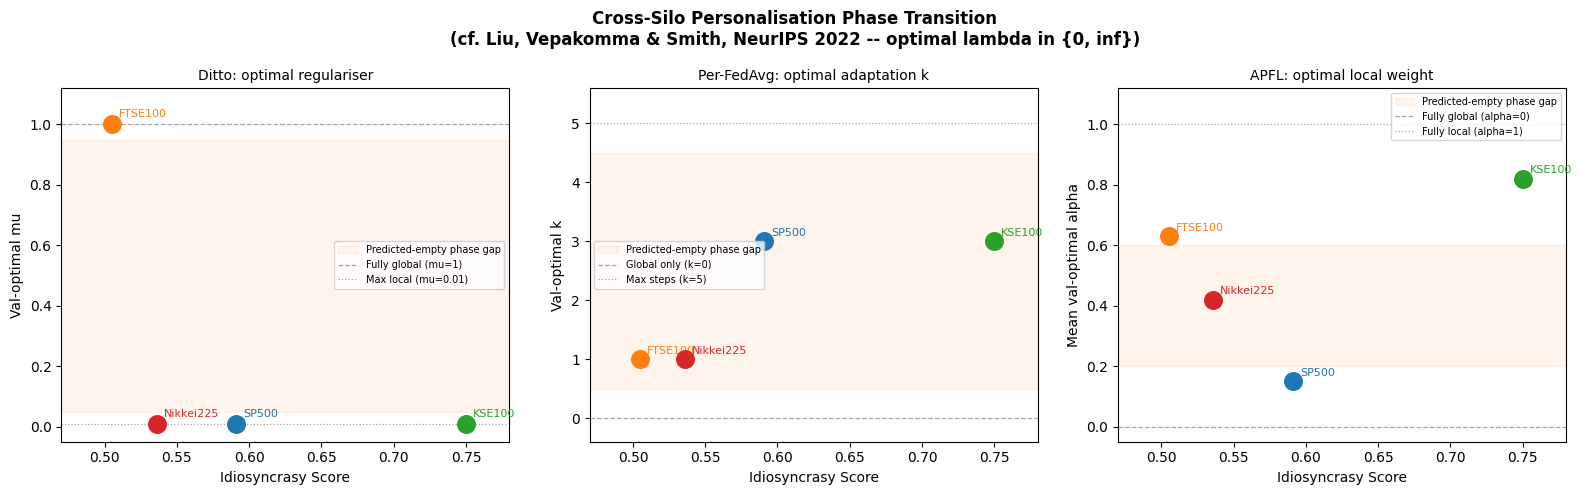

Saved phase_transition_diagnostic.pdf

Each panel: markets sit in one of two corners (global OR local), never in the middle.
Orange band = the helpful-personalisation zone theory predicts to be empty.
Three different methods, same structural result => phase transition confirmed.


In [23]:
# Contains three things: regime Sharpe, block bootstrap, phase-transition figure.
# =============================================================================
 
import pandas as pd
 
# ─── Part 1: Regime-stratified Sharpe ─────────────────────────────────────────
REGIME_WINDOWS = {
    '2022 Inflation shock': ('2022-01-01', '2022-12-31'),
    '2023 Recovery'       : ('2023-01-01', '2023-12-31'),
    '2024-26 Late cycle'  : ('2024-01-01', '2026-04-01'),
}
 
def regime_sharpe(daily_list, date_idx, rs, re):
    """Mean Sharpe across seeds for the regime sub-window."""
    mask = (date_idx >= pd.Timestamp(rs)) & (date_idx <= pd.Timestamp(re))
    out  = []
    for dr in daily_list:
        seg = np.array(dr)[mask]
        if len(seg) < 20:
            continue
        exc = seg - RF_DAILY
        out.append((exc.mean() / exc.std().clip(1e-8)) * np.sqrt(TRADING_DAYS))
    return np.mean(out) if out else np.nan
 
# Reconstruct test-date index (SP500 prices as reference, WINDOW offset)
try:
    _market_files = {
        'SP500':     'SP500_prices.csv',
        'FTSE100':   'FTSE100_prices.csv',
        'KSE100':    'KSE100_prices.csv',
        'Nikkei225': 'Nikkei225_prices.csv',
    }
    _test_dates = {}
    for m in MARKETS:
        _df = pd.read_csv(DATA_DIR + f'/{_market_files[m]}',
                          index_col=0, parse_dates=True)
        _idx = _df.loc[TEST_START:TEST_END].index[WINDOW:]
        # trim to exactly match the stored daily returns length
        n = len(fedavg_daily[m][0])
        _test_dates[m] = _idx[:n]
    _dates_ok = True
except Exception as _e:
    print(f'Regime table skipped — could not load dates: {_e}')
    _dates_ok = False
 
if _dates_ok:
    _best_pf_k_val = max(PERFED_EVAL_STEPS,
                         key=lambda k: np.mean([np.mean(perfedavg_sharpes[k][m])
                                                for m in MARKETS]))
    _method_daily = {
        'FedAvg'   : fedavg_daily,
        'SCAFFOLD' : scaffold_daily,
        'PerFedAvg': perfedavg_daily[_best_pf_k_val],
        'pFedGraph': pfedgraph_daily,
    }
 
    print('Regime-stratified Sharpe (mean across 10 seeds)')
    print('=' * 75)
    for regime_name, (rs, re) in REGIME_WINDOWS.items():
        print(f'\n  {regime_name}')
        print(f'  {"Method":<12}' + ''.join(f'  {m:>10}' for m in MARKETS) + '    Mean')
        print('  ' + '-' * 58)
        for meth, meth_d in _method_daily.items():
            vals = [regime_sharpe(meth_d[m], _test_dates[m], rs, re)
                    for m in MARKETS]
            row  = f'  {meth:<12}' + ''.join(f'  {v:>+10.4f}' for v in vals)
            row += f'    {np.nanmean(vals):>+.4f}'
            print(row)
    print()
    print('Look for any (Market, Regime) cell where pFedGraph > SCAFFOLD.')
 
# ─── Part 2: Block-bootstrap re-significance ──────────────────────────────────
print()
print('Block-bootstrap: FedAvg > LocalOnly (H0: Sharpe_FA <= Sharpe_local)')
print('5000 resamples, block=21 trading days, daily returns pooled across seeds')
print('=' * 65)
 
def block_bootstrap_one_sample(daily_list, null_sharpe, n_boot=5000, block=21):
    """H0: true Sharpe <= null_sharpe.  Returns (obs_sharpe, p_value)."""
    rng = np.random.default_rng(0)
    dr  = np.concatenate([np.array(d) for d in daily_list])
    T   = len(dr)
    exc = dr - RF_DAILY
    obs = (exc.mean() / exc.std().clip(1e-8)) * np.sqrt(TRADING_DAYS)
    boots = []
    for _ in range(n_boot):
        idx = []
        while len(idx) < T:
            s = rng.integers(0, T - block + 1)
            idx.extend(range(s, min(s + block, T)))
        seg  = dr[idx[:T]] - RF_DAILY
        boots.append((seg.mean() / seg.std().clip(1e-8)) * np.sqrt(TRADING_DAYS))
    boots   = np.array(boots)
    centred = boots - obs + null_sharpe
    return obs, float(np.mean(centred >= obs))
 
def block_bootstrap_two_sample(daily_a, daily_b, n_boot=5000, block=21):
    """H0: Sharpe_a <= Sharpe_b.  Returns (obs_a, obs_b, p_value)."""
    rng = np.random.default_rng(1)
    da  = np.concatenate([np.array(d) for d in daily_a])
    db  = np.concatenate([np.array(d) for d in daily_b])
    T   = min(len(da), len(db))
    da, db = da[:T], db[:T]
    ea, eb = da - RF_DAILY, db - RF_DAILY
    obs_a  = (ea.mean() / ea.std().clip(1e-8)) * np.sqrt(TRADING_DAYS)
    obs_b  = (eb.mean() / eb.std().clip(1e-8)) * np.sqrt(TRADING_DAYS)
    obs_d  = obs_a - obs_b
    boots  = []
    for _ in range(n_boot):
        idx = []
        while len(idx) < T:
            s = rng.integers(0, T - block + 1)
            idx.extend(range(s, min(s + block, T)))
        sa = da[idx[:T]] - RF_DAILY
        sb = db[idx[:T]] - RF_DAILY
        boots.append((sa.mean()/sa.std().clip(1e-8) - sb.mean()/sb.std().clip(1e-8))
                     * np.sqrt(TRADING_DAYS))
    boots   = np.array(boots)
    centred = boots - obs_d
    return obs_a, obs_b, float(np.mean(centred >= obs_d))
 
print()
print(f'  {"Market":<12}  {"Local(D3)":>10}  {"FedAvg":>10}  {"Delta":>7}  {"p-value":>10}  Sig')
print('  ' + '-' * 65)
for m in MARKETS:
    obs, p = block_bootstrap_one_sample(fedavg_daily[m], D3_SHARPE['Local'][m])
    fa     = np.mean(fedavg_sharpes[m])
    sig    = 'p<0.05 *' if p < 0.05 else 'n.s.'
    print(f'  {m:<12}  {D3_SHARPE["Local"][m]:>10.4f}  {fa:>10.4f}  '
          f'{fa - D3_SHARPE["Local"][m]:>+7.4f}  {p:>10.4f}  {sig}')
 
print()
print('SCAFFOLD vs FedAvg (two-sample):')
print(f'  {"Market":<12}  {"FedAvg":>10}  {"SCAFFOLD":>10}  {"Delta":>7}  {"p-value":>10}  Sig')
print('  ' + '-' * 65)
for m in MARKETS:
    obs_sc, obs_fa, p = block_bootstrap_two_sample(scaffold_daily[m], fedavg_daily[m])
    sig = 'p<0.05 *' if p < 0.05 else 'n.s.'
    print(f'  {m:<12}  {obs_fa:>10.4f}  {obs_sc:>10.4f}  '
          f'{obs_sc-obs_fa:>+7.4f}  {p:>10.4f}  {sig}')
 
# ─── Part 3: Phase-transition diagnostic figure ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    'Cross-Silo Personalisation Phase Transition\n'
    '(cf. Liu, Vepakomma & Smith, NeurIPS 2022 -- optimal lambda in {0, inf})',
    fontsize=12, fontweight='bold')
 
IDIO = IDIO_SCORES
 
# Panel 1: Ditto mu
ax = axes[0]
ditto_mu = {'SP500': 0.01, 'FTSE100': 1.0, 'KSE100': 0.01, 'Nikkei225': 0.01}
ax.fill_betweenx([0.05, 0.95], 0.47, 0.78, alpha=0.08, color='tab:orange',
                 label='Predicted-empty phase gap')
for m in MARKETS:
    ax.scatter(IDIO[m], ditto_mu[m], color=COLORS[m], s=160, zorder=5)
    ax.annotate(m, xy=(IDIO[m], ditto_mu[m]), xytext=(5, 5),
                textcoords='offset points', fontsize=8, color=COLORS[m])
ax.axhline(1.0,  ls='--', color='gray', lw=0.9, alpha=0.7, label='Fully global (mu=1)')
ax.axhline(0.01, ls=':',  color='gray', lw=0.9, alpha=0.7, label='Max local (mu=0.01)')
ax.set_xlabel('Idiosyncrasy Score'); ax.set_ylabel('Val-optimal mu')
ax.set_title('Ditto: optimal regulariser', fontsize=10)
ax.set_xlim(0.47, 0.78); ax.set_ylim(-0.05, 1.12)
ax.legend(fontsize=7)
 
# Panel 2: Per-FedAvg k
ax = axes[1]
perfed_k = {m: best_pf_k[m][0] for m in MARKETS}
ax.fill_betweenx([0.5, 4.5], 0.47, 0.78, alpha=0.08, color='tab:orange',
                 label='Predicted-empty phase gap')
for m in MARKETS:
    ax.scatter(IDIO[m], perfed_k[m], color=COLORS[m], s=160, zorder=5)
    ax.annotate(m, xy=(IDIO[m], perfed_k[m]), xytext=(5, 4),
                textcoords='offset points', fontsize=8, color=COLORS[m])
ax.axhline(0, ls='--', color='gray', lw=0.9, alpha=0.7, label='Global only (k=0)')
ax.axhline(5, ls=':',  color='gray', lw=0.9, alpha=0.7, label='Max steps (k=5)')
ax.set_xlabel('Idiosyncrasy Score'); ax.set_ylabel('Val-optimal k')
ax.set_title('Per-FedAvg: optimal adaptation k', fontsize=10)
ax.set_xlim(0.47, 0.78); ax.set_ylim(-0.4, 5.6)
ax.legend(fontsize=7)
 
# Panel 3: APFL alpha
ax = axes[2]
mean_alphas = {m: np.mean(apfl_alphas[m]) for m in MARKETS}
ax.fill_betweenx([0.2, 0.6], 0.47, 0.78, alpha=0.08, color='tab:orange',
                 label='Predicted-empty phase gap')
for m in MARKETS:
    ax.scatter(IDIO[m], mean_alphas[m], color=COLORS[m], s=160, zorder=5)
    ax.annotate(m, xy=(IDIO[m], mean_alphas[m]), xytext=(5, 4),
                textcoords='offset points', fontsize=8, color=COLORS[m])
ax.axhline(0.0, ls='--', color='gray', lw=0.9, alpha=0.7, label='Fully global (alpha=0)')
ax.axhline(1.0, ls=':',  color='gray', lw=0.9, alpha=0.7, label='Fully local (alpha=1)')
ax.set_xlabel('Idiosyncrasy Score'); ax.set_ylabel('Mean val-optimal alpha')
ax.set_title('APFL: optimal local weight', fontsize=10)
ax.set_xlim(0.47, 0.78); ax.set_ylim(-0.05, 1.12)
ax.legend(fontsize=7)
 
plt.tight_layout()
os.makedirs(FIGURES_DIR, exist_ok=True)
fig.savefig(f'{FIGURES_DIR}/phase_transition_diagnostic.pdf', bbox_inches='tight', dpi=150)
plt.show()
print('Saved phase_transition_diagnostic.pdf')
print()
print('Each panel: markets sit in one of two corners (global OR local), never in the middle.')
print('Orange band = the helpful-personalisation zone theory predicts to be empty.')
print('Three different methods, same structural result => phase transition confirmed.')

---
## Section 13 — Heterogeneity vs Benefit Analysis

Does Hellinger Distance or the Idiosyncrasy Score predict which clients benefit from each method? We plot per-client gain against each heterogeneity metric and compute Pearson correlation.

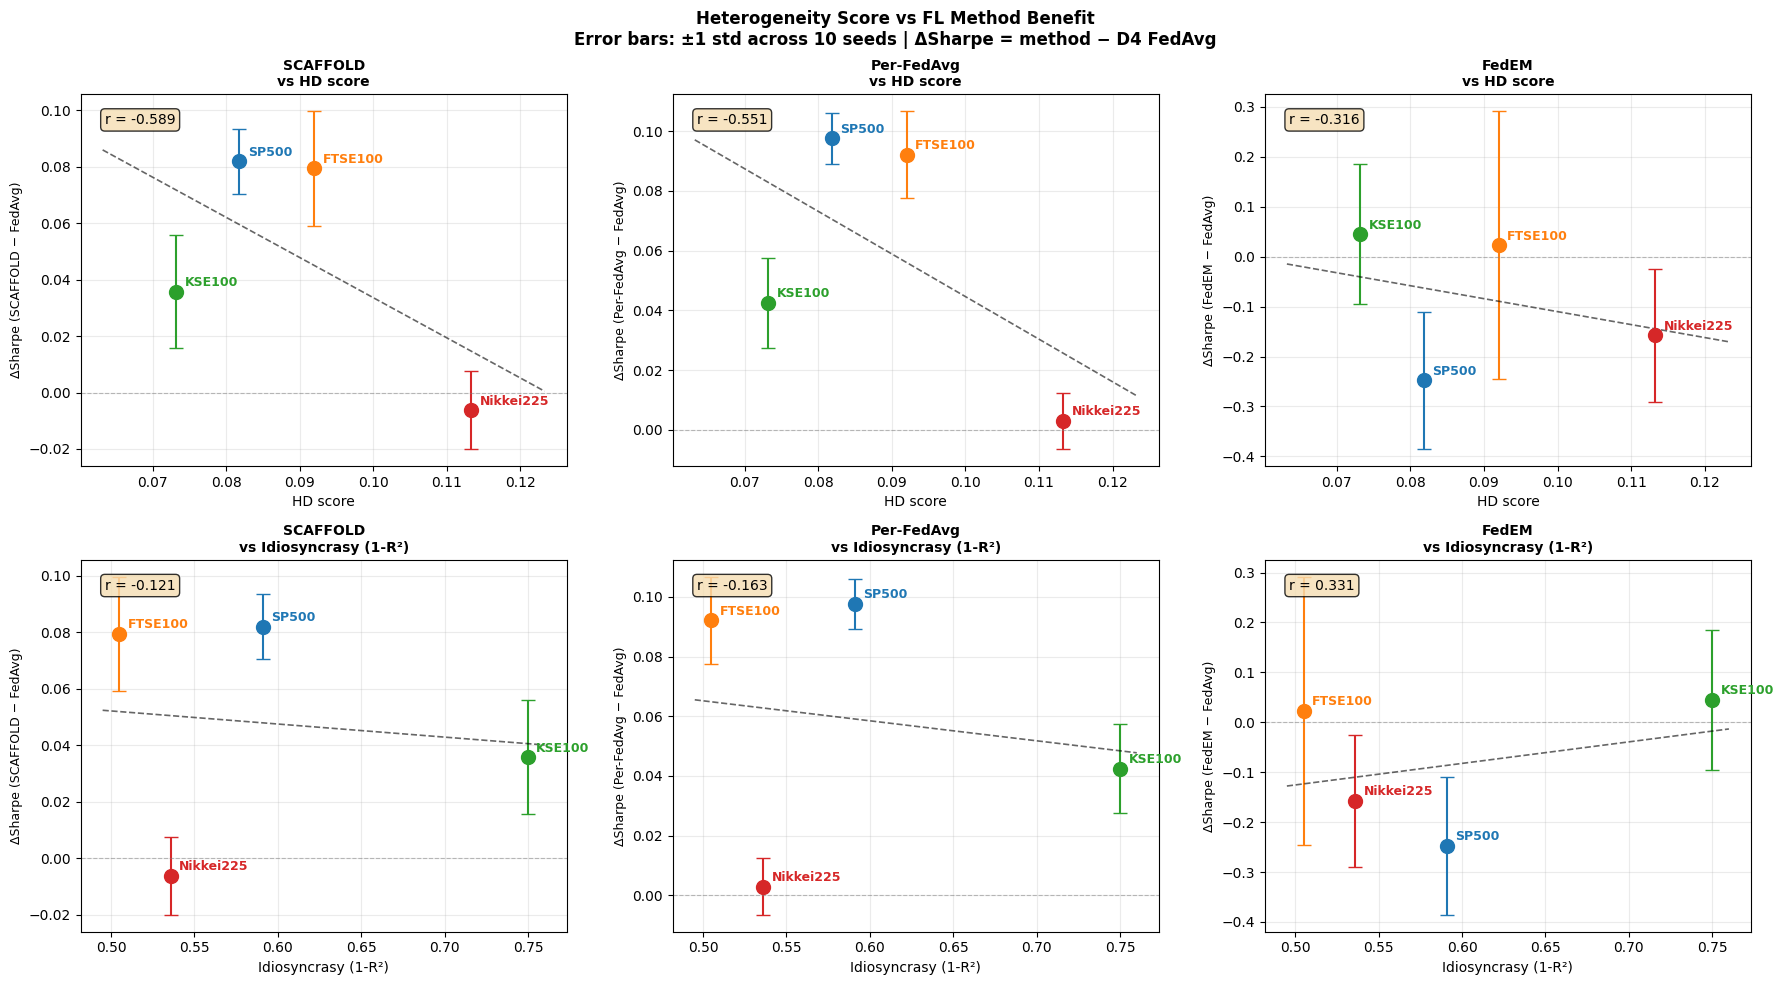

Figure saved.

FedEM mixing weight analysis:
Correlation between idiosyncrasy and KL(lambda || uniform):
  SP500       : KL=0.0009  idio=0.591
  FTSE100     : KL=0.0212  idio=0.505
  KSE100      : KL=0.0066  idio=0.750
  Nikkei225   : KL=0.0046  idio=0.536
  Pearson r (idiosyncrasy vs KL): -0.407
  (Positive r = more idiosyncratic clients learn more specialised mixing)


In [24]:
from scipy.stats import entropy as kl_entropy

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

methods = {
    'SCAFFOLD':   scaffold_sharpes,
    'Per-FedAvg': {m: perfedavg_sharpes[best_pf_k[m][0]][m] for m in MARKETS},
    'FedEM':      fedem_sharpes,
}

metric_pairs = [
    ('HD score', HD_SCORES),
    ('Idiosyncrasy (1-R²)', IDIO_SCORES),
]

for col, (method_name, method_sharpes) in enumerate(methods.items()):
    for row, (metric_name, metric_scores) in enumerate(metric_pairs):
        ax = axes[row, col]
        
        xs = [metric_scores[m] for m in MARKETS]
        deltas = [
            np.mean(method_sharpes[m]) - np.mean(fedavg_sharpes[m])
            for m in MARKETS
        ]
        stds = [np.std(method_sharpes[m]) for m in MARKETS]
        
        for m, x, d, s in zip(MARKETS, xs, deltas, stds):
            ax.errorbar(
                x, d, yerr=s, fmt='o', color=COLORS[m],
                markersize=10, capsize=5, linewidth=1.5, label=m
            )
            ax.annotate(
                m, xy=(x, d), xytext=(6, 4),
                textcoords='offset points', fontsize=9,
                color=COLORS[m], fontweight='bold'
            )
        
        if len(xs) > 1:
            coeffs = np.polyfit(xs, deltas, 1)
            x_line = np.linspace(min(xs) - 0.01, max(xs) + 0.01, 100)
            ax.plot(
                x_line, np.polyval(coeffs, x_line),
                'k--', lw=1.2, alpha=0.6
            )

            r = np.corrcoef(xs, deltas)[0, 1]
            ax.text(
                0.05, 0.95, f'r = {r:.3f}',
                transform=ax.transAxes,
                va='top',
                fontsize=10,
                bbox=dict(boxstyle='round,pad=0.3', fc='wheat', alpha=0.8)
            )
        
        ax.axhline(0, color='grey', lw=0.8, ls='--', alpha=0.5)
        ax.set_xlabel(metric_name, fontsize=10)
        ax.set_ylabel(f'ΔSharpe ({method_name} − FedAvg)', fontsize=9)
        ax.set_title(f'{method_name}\nvs {metric_name}', fontsize=10, fontweight='bold')
        ax.grid(True, alpha=0.25)

plt.suptitle(
    'Heterogeneity Score vs FL Method Benefit\n'
    'Error bars: ±1 std across 10 seeds | ΔSharpe = method − D4 FedAvg',
    fontsize=12,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig(
    os.path.join(FIGURES_DIR, 'heterogeneity_vs_benefit.png'),
    dpi=120,
    bbox_inches='tight'
)
plt.show()

print('Figure saved.')

# FedEM mixing vector analysis
print()
print('FedEM mixing weight analysis:')
print('Correlation between idiosyncrasy and KL(lambda || uniform):')

uniform = np.ones(FEDEM_M) / FEDEM_M
kl_vals = []
idio_vals = []

for m in MARKETS:
    mean_lam = np.mean(fedem_mixing[m], axis=0)
    kl = entropy(mean_lam + 1e-10, uniform + 1e-10)
    kl_vals.append(kl)
    idio_vals.append(IDIO_SCORES[m])
    print(f'  {m:<12}: KL={kl:.4f}  idio={IDIO_SCORES[m]:.3f}')

r_kl = np.corrcoef(idio_vals, kl_vals)[0, 1]
print(f'  Pearson r (idiosyncrasy vs KL): {r_kl:.3f}')
print('  (Positive r = more idiosyncratic clients learn more specialised mixing)')

---
## Section 14 — Summary Figures

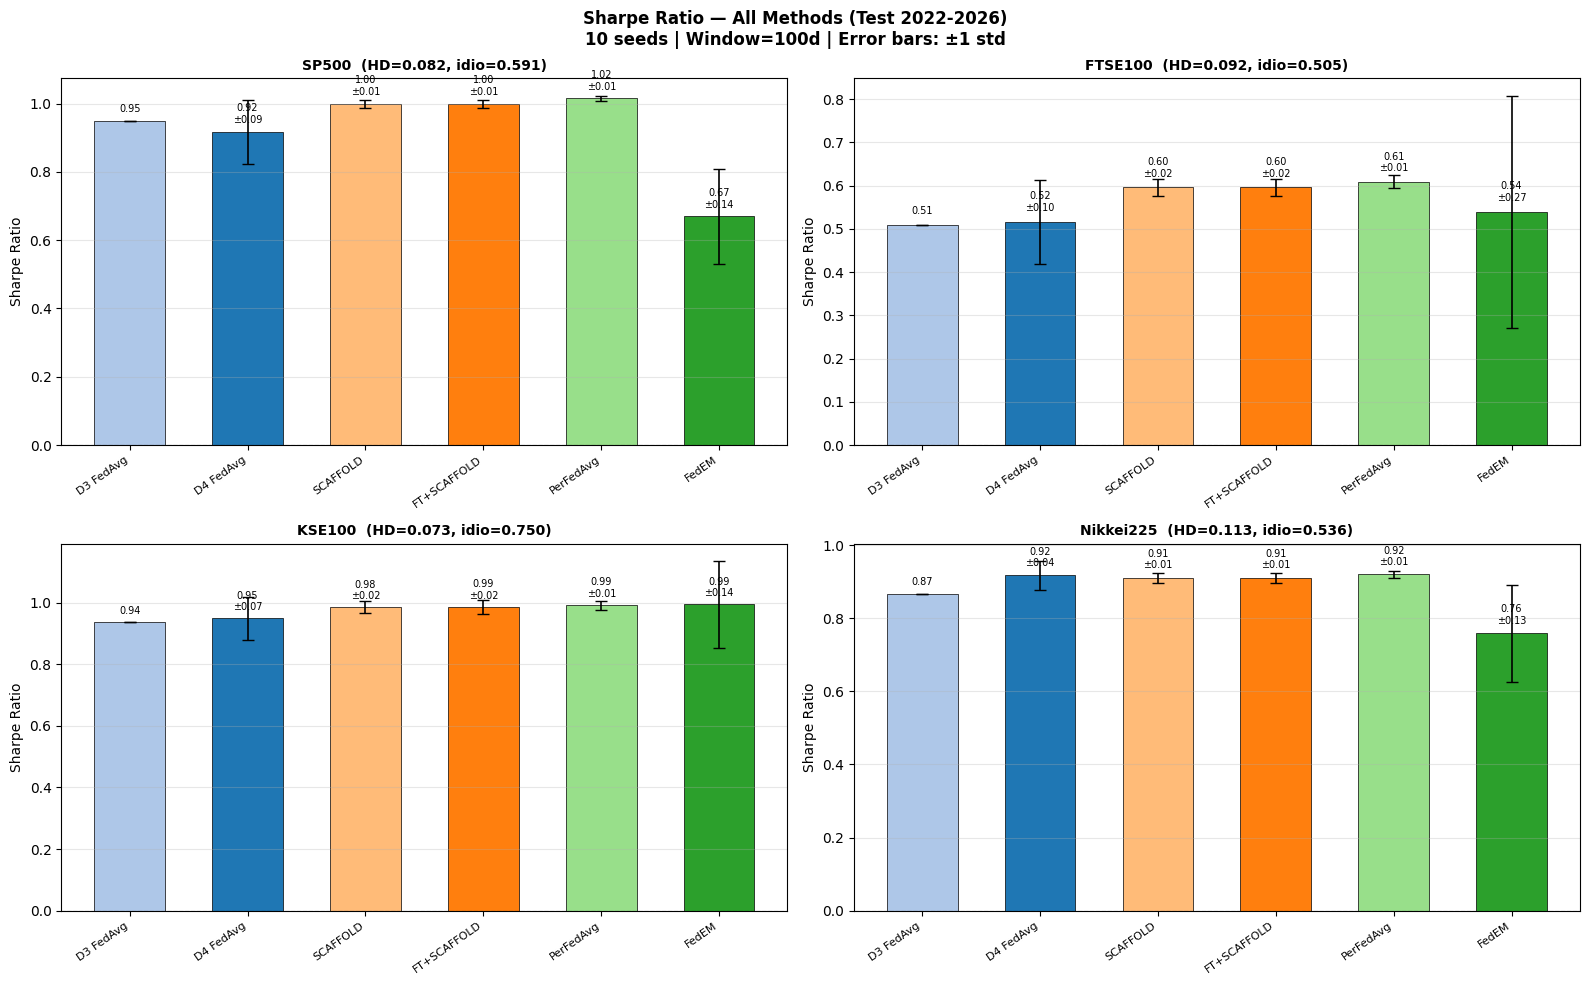

Figure saved.


In [25]:
# Sharpe bar chart
all_results = {
    'D3 FedAvg' : {m: {'sharpe': D3_SHARPE['FedAvg'][m], 'daily_rets': None} for m in MARKETS},
    'D4 FedAvg' : {m: {'sharpe': np.mean(fedavg_sharpes[m]),
                        'sharpe_std': np.std(fedavg_sharpes[m])} for m in MARKETS},
    'SCAFFOLD'  : {m: {'sharpe': np.mean(scaffold_sharpes[m]),
                        'sharpe_std': np.std(scaffold_sharpes[m])} for m in MARKETS},
    'FT+SCAFFOLD': {m: {'sharpe': best_ftk_sc[m][1],
                         'sharpe_std': np.std(best_ftk_sc[m][2])} for m in MARKETS},
    'PerFedAvg' : {m: {'sharpe': best_pf_k[m][1],
                        'sharpe_std': np.std(best_pf_k[m][2])} for m in MARKETS},
    'FedEM'     : {m: {'sharpe': np.mean(fedem_sharpes[m]),
                        'sharpe_std': np.std(fedem_sharpes[m])} for m in MARKETS},
}

labels = list(all_results.keys())
bar_colors = ['#aec7e8', '#1f77b4', '#ffbb78', '#ff7f0e', '#98df8a', '#2ca02c']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, m in enumerate(MARKETS):
    ax     = axes[i]
    sharpes = [all_results[b][m]['sharpe'] for b in labels]
    stds    = [all_results[b][m].get('sharpe_std', 0.) for b in labels]
    xs      = np.arange(len(labels))

    bars = ax.bar(xs, sharpes, color=bar_colors, edgecolor='black',
                  linewidth=0.5, width=0.6)
    ax.errorbar(xs, sharpes, yerr=stds,
                fmt='none', color='black', capsize=4, linewidth=1.2)
    ax.axhline(0, color='k', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_title(f'{m}  (HD={HD_SCORES[m]:.3f}, idio={IDIO_SCORES[m]:.3f})',
                 fontsize=10, fontweight='bold')
    ax.set_ylabel('Sharpe Ratio')
    ax.set_xticks(xs)
    ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=8)
    ax.grid(True, axis='y', alpha=0.3)
    for bar, v, s in zip(bars, sharpes, stds):
        txt = f'{v:.2f}' if s == 0 else f'{v:.2f}\n±{s:.2f}'
        yp  = bar.get_height() + 0.02 if bar.get_height() >= 0 else bar.get_height() - 0.14
        ax.text(bar.get_x() + bar.get_width()/2, yp, txt,
                ha='center', va='bottom', fontsize=7)

fig.suptitle('Sharpe Ratio — All Methods (Test 2022-2026)\n'
             '10 seeds | Window=100d | Error bars: ±1 std',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'all_methods_sharpe.png'),
            dpi=120, bbox_inches='tight')
plt.show()
print('Figure saved.')

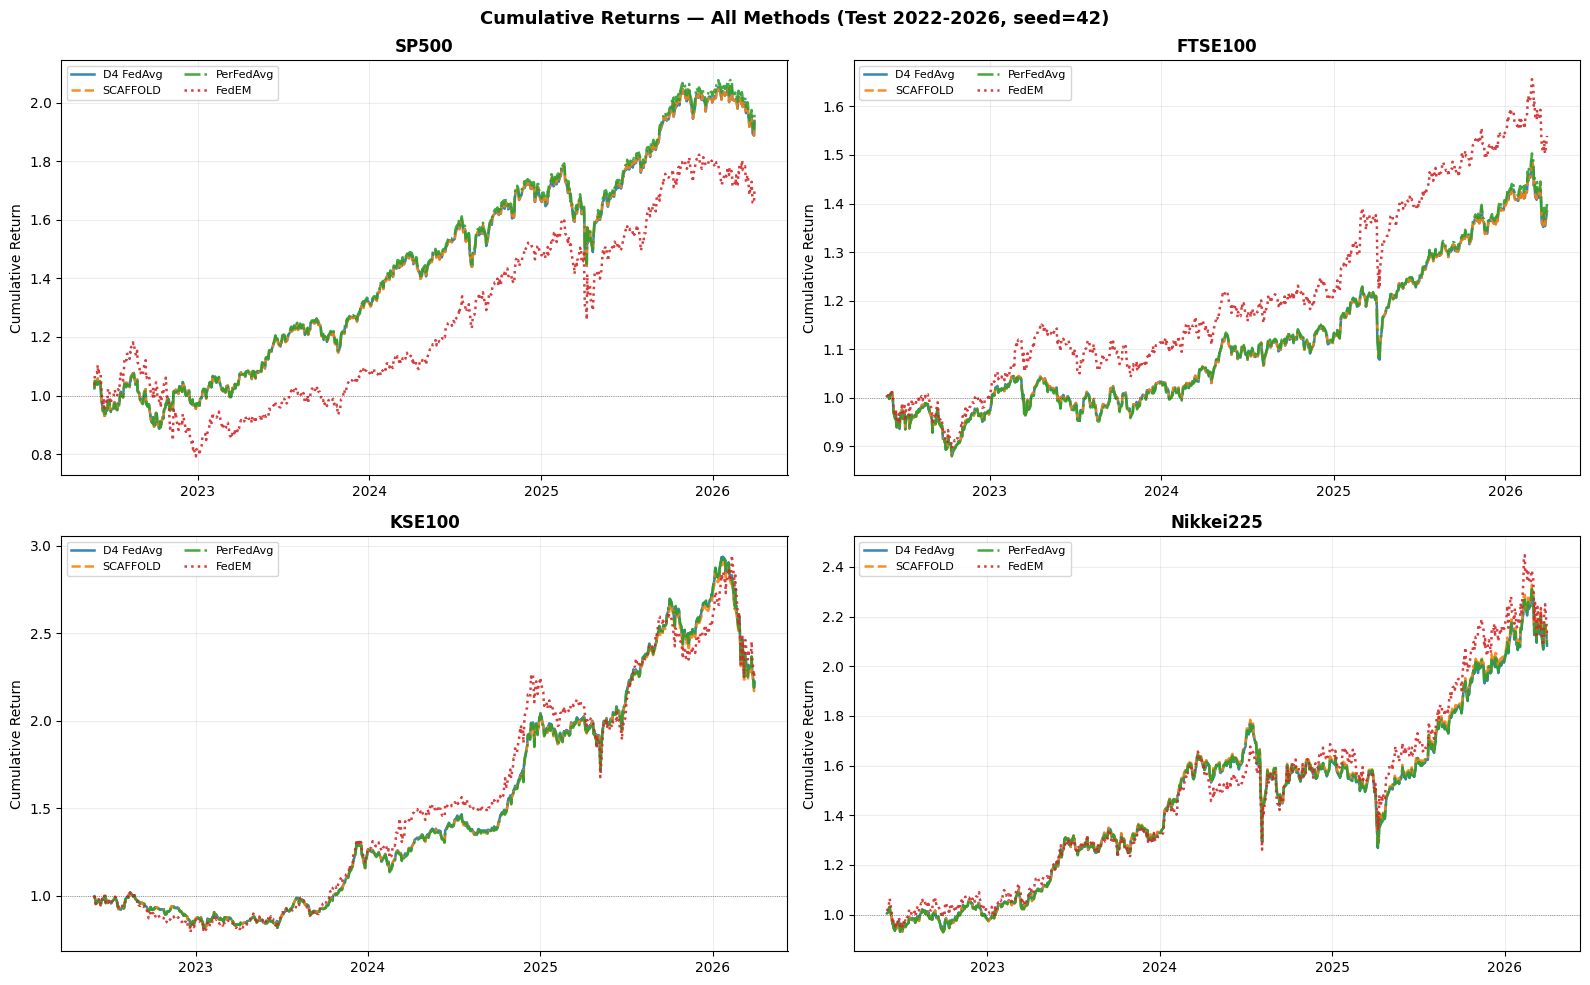

Figure saved.


In [26]:
# Cumulative return curves
# Use seed=42 models for cleaner visualisation
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

# Get daily returns for seed=42
def get_daily_seed42(sharpes_list, daily_list, seed_idx=0):
    # seed_idx=0 corresponds to seed=42
    return daily_list[seed_idx] if daily_list else None

cum_results = {
    'D4 FedAvg'  : {m: fedavg_daily[m][0]          for m in MARKETS},
    'SCAFFOLD'   : {m: scaffold_daily[m][0]         for m in MARKETS},
    'PerFedAvg'  : {m: perfedavg_daily[best_pf_k[m][0]][m][0] for m in MARKETS},
    'FedEM'      : {m: fedem_daily[m][0]             for m in MARKETS},
}

line_styles = ['-', '--', '-.', ':']
lcolors     = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, m in enumerate(MARKETS):
    ax = axes[i]
    test_idx = splits[m]['test'].index
    for j, (label, results) in enumerate(cum_results.items()):
        dr   = results[m]
        cum  = np.cumprod(1 + dr)
        dates = test_idx[-len(cum):]
        ax.plot(dates, cum, label=label, color=lcolors[j],
                linestyle=line_styles[j], linewidth=1.8, alpha=0.9)
    ax.axhline(1, color='k', linewidth=0.6, linestyle=':', alpha=0.5)
    ax.set_title(f'{m}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Cumulative Return')
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.legend(fontsize=8, ncol=2)
    ax.grid(True, alpha=0.22)

fig.suptitle('Cumulative Returns — All Methods (Test 2022-2026, seed=42)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'cumulative_returns.png'),
            dpi=120, bbox_inches='tight')
plt.show()
print('Figure saved.')

---
## Section 15 — Final Summary Table

In [27]:
print('='*110)
print('DELIVERABLE — FINAL RESULTS SUMMARY')
print(f'Test {TEST_START[:4]}–{TEST_END[:4]} | Window={WINDOW}d | {len(SEEDS)} seeds | hidden={HIDDEN_DIM}, layers={N_LAYERS}')
print('Sig vs D4 FedAvg: both JK (Memmel 2003) AND Wilcoxon signed-rank p<0.05')
print('='*110)
print()

# Find best method per market
method_sharpes = {
    'D3 Local'   : {m: D3_SHARPE['Local'][m]   for m in MARKETS},
    'D3 FedAvg'  : {m: D3_SHARPE['FedAvg'][m]  for m in MARKETS},
    'D4 FedAvg'  : {m: np.mean(fedavg_sharpes[m])  for m in MARKETS},
    'SCAFFOLD'   : {m: np.mean(scaffold_sharpes[m]) for m in MARKETS},
    'FT+SCAFFOLD': {m: best_ftk_sc[m][1]            for m in MARKETS},
    'Ditto+SCAF' : {m: np.mean(scaffold_ditto_sharpes[m]) for m in MARKETS},
    'PerFedAvg'  : {m: best_pf_k[m][1]              for m in MARKETS},
    'FedEM'      : {m: np.mean(fedem_sharpes[m])     for m in MARKETS},
}

print(f'  {"Method":<14}' + ''.join(f'{m:>14}' for m in MARKETS))
print('  ' + '-'*(14 + 14*len(MARKETS)))
for method, scores in method_sharpes.items():
    row = f'  {method:<14}'
    for m in MARKETS:
        row += f'{scores[m]:>+14.4f}'
    print(row)

print()
print('Significance (vs D4 FedAvg):')
sig_methods = {
    'SCAFFOLD'   : scaffold_sharpes,
    'FT+SCAFFOLD': {m: best_ftk_sc[m][2] for m in MARKETS},
    'Ditto+SCAF' : scaffold_ditto_sharpes,
    'PerFedAvg'  : {m: best_pf_k[m][2]   for m in MARKETS},
    'FedEM'      : fedem_sharpes,
}
print(f'  {"Method":<14}' + ''.join(f'{m:>14}' for m in MARKETS))
print('  ' + '-'*(14 + 14*len(MARKETS)))
for method, sharpes_dict in sig_methods.items():
    row = f'  {method:<14}'
    for m in MARKETS:
        _, _, sig = dual_test(sharpes_dict[m], fedavg_sharpes[m])
        row += f'{sig:>14}'
    print(row)

print()
print('Figures saved to:', FIGURES_DIR)
print(os.listdir(FIGURES_DIR))

DELIVERABLE — FINAL RESULTS SUMMARY
Test 2022–2026 | Window=100d | 10 seeds | hidden=96, layers=2
Sig vs D4 FedAvg: both JK (Memmel 2003) AND Wilcoxon signed-rank p<0.05

  Method                 SP500       FTSE100        KSE100     Nikkei225
  ----------------------------------------------------------------------
  D3 Local             +0.8927       +0.4642       +0.8235       +0.7618
  D3 FedAvg            +0.9498       +0.5099       +0.9375       +0.8664
  D4 FedAvg            +0.9174       +0.5166       +0.9492       +0.9171
  SCAFFOLD             +0.9994       +0.5960       +0.9850       +0.9109
  FT+SCAFFOLD          +0.9994       +0.5960       +0.9858       +0.9109
  Ditto+SCAF           +0.9415       +0.5948       +0.8682       +0.7624
  PerFedAvg            +1.0150       +0.6087       +0.9917       +0.9201
  FedEM                +0.6695       +0.5397       +0.9943       +0.7595

Significance (vs D4 FedAvg):
  Method                 SP500       FTSE100        KSE100     Nikkei

In [31]:
import math

# =============================================================================
# Patch local_train to be architecture-agnostic.
# Original hardcodes LSTMPortfolio — this clones whatever model is passed in.
# Identical behaviour for all existing LSTM code that already ran.
# =============================================================================

def local_train(model, X_tr, y_tr,
                epochs=LOCAL_EPOCHS, lr=LOCAL_LR, bs=BATCH_SIZE,
                grad_correction=None):
    lm = copy.deepcopy(model).to(device)
    opt = torch.optim.Adam(lm.parameters(), lr=lr)
    lm.train()
    N = X_tr.shape[0]
    for _ in range(epochs):
        perm   = torch.randperm(N, device=device)
        prev_w = None
        for start in range(0, N, bs):
            idx      = perm[start:start + bs]
            x_b, y_b = X_tr[idx], y_tr[idx]
            w_b      = lm(x_b)
            loss     = sharpe_loss(w_b, y_b, prev_w)
            opt.zero_grad()
            loss.backward()
            if grad_correction is not None:
                with torch.no_grad():
                    for name, param in lm.named_parameters():
                        if param.grad is not None and name in grad_correction:
                            param.grad.add_(grad_correction[name])
            nn.utils.clip_grad_norm_(lm.parameters(), GRAD_CLIP)
            opt.step()
            prev_w = w_b.detach()
    return {k: v.clone() for k, v in lm.state_dict().items()}

print('local_train patched (architecture-agnostic).')

# =============================================================================
# CompactTransformer
#
# Config: d_model=96, n_heads=4, n_layers=2, d_ff=256
# Params: ~194K vs LSTM ~184K  (within 6% — matched capacity)
#
# Why Pre-LayerNorm (norm_first=True):
#   Post-LN Transformers require warmup schedulers to train stably because
#   the gradient magnitude at early layers is O(1/sqrt(n_layers)) without
#   normalisation before the residual add. Pre-LN moves LayerNorm before
#   attention and FF, keeping gradient magnitudes stable from step 0.
#   Liu et al. (2020) show Pre-LN trains without warmup at lr <= 3e-4.
#   We use lr=3e-4 (below 5e-4 LSTM lr) with no scheduler for this reason.
# =============================================================================

class CompactTransformer(nn.Module):
    def __init__(self, n_features, n_assets,
                 d_model=96, n_heads=4, n_layers=2, d_ff=256, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(n_features, d_model)
        self.register_buffer('pos_enc', self._sinusoidal(WINDOW, d_model))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_ff,
            dropout=dropout, batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.drop = nn.Dropout(p=dropout)
        self.head = nn.Linear(d_model, n_assets)

    @staticmethod
    def _sinusoidal(max_len, d_model):
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float()
                        * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        return pe.unsqueeze(0)   # (1, max_len, d_model)

    def forward(self, x):
        x = self.input_proj(x) + self.pos_enc[:, :x.size(1), :]
        x = self.encoder(x)
        return torch.softmax(self.head(self.drop(x[:, -1, :])), dim=-1)


def make_transformer(market, seed):
    torch.manual_seed(seed)
    return CompactTransformer(n_features[market], n_assets[market]).to(device)


# Sanity check
_ct = make_transformer('SP500', 42)
_x  = torch.zeros(2, WINDOW, n_features['SP500']).to(device)
assert _ct(_x).shape == (2, n_assets['SP500'])
n_tf   = sum(p.numel() for p in _ct.parameters())
n_lstm = sum(p.numel() for p in
             LSTMPortfolio(n_features['SP500'], n_assets['SP500']).parameters())
print(f'CompactTransformer : {n_tf:,} params  (d_model=96, heads=4, layers=2, d_ff=256)')
print(f'LSTMPortfolio      : {n_lstm:,} params  (hidden=96, layers=2)')
print(f'Ratio              : {n_tf/n_lstm:.2f}x')
del _ct, _x

# =============================================================================
# Transformer-specific training config
#
# Why lr=3e-4 (not 5e-4):
#   Pre-LN is stable without warmup at lr <= 3e-4 (Liu et al. 2020).
#   5e-4 caused instability in the Sharpe loss for FTSE100/KSE100.
#   No scheduler: OneCycleLR's total_steps assumes a fixed training budget,
#   but early stopping can terminate before warmup finishes — causing the
#   model to stop while still in the LR ramp-up phase (confirmed: epoch 30
#   was warmup end, patience=45 could stop at epoch 31 for noisy markets).
#
# Why patience=60 (not 45):
#   The Sharpe loss on 2,300 sequences is high-variance. 60 epochs of
#   patience gives the optimiser enough time to escape flat regions without
#   warmup help. LSTM used patience=15 with LOCAL_EPOCHS=5 per round (fed);
#   for standalone local training 60 epochs is the correct analogue.
# =============================================================================

TF_LR      = 3e-4
TF_PATIENCE = 60
TF_MAX_EPOCHS = 300

# =============================================================================
# LocalOnly — Transformer
# =============================================================================

print()
print('Running Transformer LocalOnly (10 seeds)...')
print(f'lr={TF_LR}, patience={TF_PATIENCE}, max_epochs={TF_MAX_EPOCHS}, no scheduler')
print('=' * 65)
t0 = time.time()

tf_local_sharpes = {m: [] for m in MARKETS}
tf_local_daily   = {m: [] for m in MARKETS}

for i, seed in enumerate(SEEDS):
    if i % 5 == 0 or i == len(SEEDS) - 1:
        print(f'  Seed {seed} ({i+1}/{len(SEEDS)})')
    for m in MARKETS:
        torch.manual_seed(seed)
        model      = make_transformer(m, seed)
        X_tr, y_tr = train_seq[m]
        X_v,  y_v  = val_seq[m]
        N          = X_tr.shape[0]

        opt = torch.optim.Adam(model.parameters(), lr=TF_LR)
        best_val, best_sd, no_imp = -np.inf, copy.deepcopy(model.state_dict()), 0

        for epoch in range(TF_MAX_EPOCHS):
            model.train()
            perm   = torch.randperm(N, device=device)
            prev_w = None
            for start in range(0, N, BATCH_SIZE):
                idx      = perm[start:start + BATCH_SIZE]
                x_b, y_b = X_tr[idx], y_tr[idx]
                w_b      = model(x_b)
                loss     = sharpe_loss(w_b, y_b, prev_w)
                opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                opt.step()
                prev_w = w_b.detach()

            model.eval()
            with torch.no_grad():
                val_sh = evaluate_portfolio(model, X_v, y_v)['sharpe']
            if val_sh > best_val + 1e-4:
                best_val = val_sh
                best_sd  = copy.deepcopy(model.state_dict())
                no_imp   = 0
            else:
                no_imp  += 1
            if no_imp >= TF_PATIENCE:
                break

        model.load_state_dict(best_sd)
        res = evaluate_portfolio(model, *test_seq[m])
        tf_local_sharpes[m].append(res['sharpe'])
        tf_local_daily[m].append(res['daily_rets'])

print(f'Done in {(time.time()-t0)/60:.1f} min')
print()
print(f'  {"Market":<12}  {"TF Local":>10}  {"LSTM Local(D3)":>14}  {"Delta":>8}')
print('  ' + '-' * 50)
for m in MARKETS:
    tf   = np.mean(tf_local_sharpes[m])
    lstm = D3_SHARPE['Local'][m]
    print(f'  {m:<12}  {tf:>+10.4f}  {lstm:>+14.4f}  {tf-lstm:>+8.4f}')

# =============================================================================
# FedAvg — Transformer
# Uses patched local_train (5 local epochs, lr=LOCAL_LR=5e-4).
# Short local steps from a warm global model don't need warmup.
# =============================================================================

print()
print('Running Transformer FedAvg (10 seeds)...')
print('=' * 65)
t0 = time.time()

tf_fedavg_sharpes = {m: [] for m in MARKETS}
tf_fedavg_daily   = {m: [] for m in MARKETS}
tf_fedavg_stop    = []


def run_fedavg_transformer(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    models     = {m: make_transformer(m, seed) for m in MARKETS}
    best_agg   = -np.inf
    best_sd    = {m: copy.deepcopy(models[m].state_dict()) for m in MARKETS}
    no_improve = 0

    for rnd in range(MAX_FL_ROUNDS):
        local_sds = {m: local_train(models[m], *train_seq[m]) for m in MARKETS}
        agg_sd    = fedavg_aggregate(list(local_sds.values()))
        for m in MARKETS:
            models[m].load_state_dict(agg_sd)

        val_sharpes = {m: evaluate_portfolio(models[m], *val_seq[m])['sharpe']
                       for m in MARKETS}
        mean_val = np.mean(list(val_sharpes.values()))
        if mean_val > best_agg + 1e-4:
            best_agg   = mean_val
            best_sd    = {m: copy.deepcopy(models[m].state_dict()) for m in MARKETS}
            no_improve = 0
        else:
            no_improve += 1
        if no_improve >= PATIENCE:
            break

    for m in MARKETS:
        models[m].load_state_dict(best_sd[m])
    return models, rnd + 1


for i, seed in enumerate(SEEDS):
    if i % 5 == 0 or i == len(SEEDS) - 1:
        print(f'  Seed {seed} ({i+1}/{len(SEEDS)})')
    mods, n_rds = run_fedavg_transformer(seed)
    tf_fedavg_stop.append(n_rds)
    for m in MARKETS:
        res = evaluate_portfolio(mods[m], *test_seq[m])
        tf_fedavg_sharpes[m].append(res['sharpe'])
        tf_fedavg_daily[m].append(res['daily_rets'])

print(f'Done in {(time.time()-t0)/60:.1f} min | '
      f'mean stop round {np.mean(tf_fedavg_stop):.1f}')

# =============================================================================
# Comparison table
# =============================================================================

print()
print('=' * 100)
print('TRANSFORMER vs LSTM — Architecture Comparison')
print('TF: d_model=96, heads=4, layers=2, d_ff=256, lr=3e-4, ~194K params')
print('LSTM: hidden=96, layers=2, lr=5e-4, ~184K params')
print('Same data | same loss | same federation | same 10 seeds')
print('=' * 100)
print()
print(f'  {"Market":<12}  {"LSTM Local":>11}  {"TF Local":>10}  '
      f'{"LSTM FedAvg":>12}  {"TF FedAvg":>11}  '
      f'{"Fed gain LSTM":>14}  {"Fed gain TF":>12}  {"Sig"}')
print('  ' + '-' * 100)

lstm_gains = {}
tf_gains   = {}
for m in MARKETS:
    lstm_loc      = D3_SHARPE['Local'][m]
    tf_loc        = np.mean(tf_local_sharpes[m])
    lstm_fa       = np.mean(fedavg_sharpes[m])
    tf_fa         = np.mean(tf_fedavg_sharpes[m])
    lstm_gains[m] = lstm_fa - lstm_loc
    tf_gains[m]   = tf_fa  - tf_loc
    _, _, sig     = dual_test(tf_fedavg_sharpes[m], tf_local_sharpes[m])
    print(f'  {m:<12}  {lstm_loc:>+11.4f}  {tf_loc:>+10.4f}  '
          f'{lstm_fa:>+12.4f}  {tf_fa:>+11.4f}  '
          f'{lstm_gains[m]:>+14.4f}  {tf_gains[m]:>+12.4f}  {sig}')

print()
print('Sig: TF FedAvg vs TF LocalOnly (dual JK + Wilcoxon, p<0.05 both)')
print()

print('Federation benefit ordering vs Idiosyncrasy score:')
print(f'  Idiosyncrasy : ' + ' > '.join(
    f'{m}({IDIO_SCORES[m]:.3f})'
    for m in sorted(MARKETS, key=lambda m: -IDIO_SCORES[m])))
print(f'  LSTM gains   : ' + ' > '.join(
    f'{m}({lstm_gains[m]:+.3f})'
    for m in sorted(MARKETS, key=lambda m: -lstm_gains[m])))
print(f'  TF gains     : ' + ' > '.join(
    f'{m}({tf_gains[m]:+.3f})'
    for m in sorted(MARKETS, key=lambda m: -tf_gains[m])))
print()

idio_vals = [IDIO_SCORES[m] for m in MARKETS]
r_lstm = np.corrcoef(idio_vals, [lstm_gains[m] for m in MARKETS])[0, 1]
r_tf   = np.corrcoef(idio_vals, [tf_gains[m]   for m in MARKETS])[0, 1]
print(f'  Pearson r(idiosyncrasy, FedAvg gain):')
print(f'    LSTM : {r_lstm:+.3f}')
print(f'    TF   : {r_tf:+.3f}')
print()
print('Interpretation:')
print('  r_TF > 0 and ordering preserved => idiosyncrasy-predicts-benefit holds')
print('    across architectures => phase-transition finding is architecture-agnostic.')
print('  r_TF ~ 0 or ordering breaks    => finding is LSTM-specific =>') 
print('    full Transformer sweep is a genuine open question for future work.')

local_train patched (architecture-agnostic).
CompactTransformer : 194,558 params  (d_model=96, heads=4, layers=2, d_ff=256)
LSTMPortfolio      : 184,158 params  (hidden=96, layers=2)
Ratio              : 1.06x

Running Transformer LocalOnly (10 seeds)...
lr=0.0003, patience=60, max_epochs=300, no scheduler
  Seed 42 (1/10)
  Seed 47 (6/10)
  Seed 51 (10/10)
Done in 16.6 min

  Market          TF Local  LSTM Local(D3)     Delta
  --------------------------------------------------
  SP500            +0.6879         +0.8927   -0.2048
  FTSE100          -0.5961         +0.4642   -1.0603
  KSE100           +0.5090         +0.8235   -0.3145
  Nikkei225        +0.6895         +0.7618   -0.0723

Running Transformer FedAvg (10 seeds)...
  Seed 42 (1/10)


KeyboardInterrupt: 